### День 1 — Базовая модель банковских счетов (усложнённый вариант)

🎯 Цель дня
Создать расширенную и абстрактную модель банковского счёта, способную служить базой для более сложных типов счетов.

📋 Требования

1. Абстрактный класс AbstractAccount
Создать абстрактный класс, содержащий:
- 🔑 уникальный идентификатор счёта
- 👤 данные владельца
- 💰 защищённый баланс
- 📊 статус счёта: активный, замороженный, закрытый
- 🔧 абстрактные методы:
  deposit(amount)
  withdraw(amount)
  get_account_info()

In [1]:
from dataclasses import dataclass
from abc import ABC, abstractmethod

'''
@dataclass cтрока-инструкция для Python: перед тем как окончательно создать
класс ниже, пропусти его через функцию dataclass
'''

@dataclass 
class AbstractAccount(ABC):
    account_id: str
    owner: str
    _balance: float
    status: str

    @abstractmethod 
    def deposit(self, amount): #положить деньги на счёт
        ...
        
    @abstractmethod
    def withdraw(self, amount): #снять деньги со счёта
        ...
        
    @abstractmethod
    def get_account_info(self): #показать выписку по счёту
        ...    

2. Класс BankAccount
Реализовать конкретный тип счёта с расширенными возможностями:
- ✅ валидация входящих данных
- 🔒 логические статусы и запрет операций при неверных статусах
- 🆔 автоматическая генерация короткого UUID при отсутствии номера счёта
- 💱 атрибут currency: RUB, USD, EUR, KZT, CNY

3. Исключения
Создать собственные классы ошибок:
- ❄️ AccountFrozenError счёт временно заблокирован
- 🚫 AccountClosedError счёта больше не существует
- ⚠️ InvalidOperationError то, что вы просите сделать, некорректно в принципе
- 💸 InsufficientFundsError денег не хватает

4. Базовые операции
Добавить проверки:
- ✅ корректность суммы
- 🔄 проверка статуса счета
- 🛡️ защита от отрицательных значений

5. Строковое представление
Метод __str__ должен показывать:
- 🏦 тип счета
- 👤 клиента
- 🔢 последние 4 цифры номера
- 📊 статус
- 💰 баланс и валюту



In [2]:
'''__init__ возьми параметры, которые пришли в BankAccount.__init__, 
и передай их дальше — пусть AbstractAccount.__init__ сделает свою обычную работу 
(сохранит их в self.account_id, self.owner и т.д.
'''
#исключения
class AccountFrozenError(Exception):
    '''Cчёт временно заблокирован'''
    pass

class AccountClosedError(Exception):
    '''Cчёт больше не существует'''
    pass

class InvalidOperationError(Exception):
    '''То, что вы просите сделать, некорректно в принципе'''
    pass

class InsufficientFundsError(Exception):
    '''Недостаточно средств на счёте'''
    pass

class TemporaryOperationError(Exception):
    """Временная ошибка — операция сейчас невозможна, но может пройти позже (например, ночное ограничение)"""
    pass

import uuid

class BankAccount(AbstractAccount):
    def __init__(self, owner, _balance, status, account_id=None, currency="RUB"):
        #валидация входящих данных
        if not owner:
            raise InvalidOperationError("Владелец счёта не может быть пустым")
        if not isinstance(_balance, (int, float)):
            raise InvalidOperationError(f"Баланс должен быть числом, получено: {type(_balance).__name__}")
        if _balance < 0:
            raise InvalidOperationError("Баланс не может быть отрицательным")
        if status not in ["active", "frozen", "closed"]:
            raise InvalidOperationError(f"Недопустимый статус: {status}")
        #автоматическая генерация короткого UUID при отсутствии номера счёта
        if account_id is None:
            account_id = uuid.uuid4().hex[:8]
        else:
            account_id = str(account_id)
            if not account_id:
                raise InvalidOperationError("Номер счёта не может быть пустым")
        if currency not in ["RUB", "USD", "EUR", "KZT", "CNY"]:
            raise InvalidOperationError(f"Недопустимая валюта: {currency}")
        super().__init__(account_id, owner, _balance, status)
        self.currency = currency

    def deposit(self, amount): #положить деньги на счёт
        if not isinstance(amount, (int, float)):
            raise InvalidOperationError(f"Сумма должна быть числом, получено: {type(amount).__name__}")
        if amount <= 0:
            raise InvalidOperationError("Сумма операции должна быть положительной")
        if self.status == "frozen":
            raise AccountFrozenError("Счёт заморожен, операция запрещена")
        if self.status == "closed":
            raise AccountClosedError("Счёт закрыт, операция запрещена")
        if self.status != "active":
            raise InvalidOperationError(
                f"Операция разрешена только для активного счёта, текущий статус: {self.status}"
            )
        self._balance += amount   

    def withdraw(self, amount): #снять деньги со счёта
        if not isinstance(amount, (int, float)):
            raise InvalidOperationError(f"Сумма должна быть числом, получено: {type(amount).__name__}")
        if amount <= 0:
            raise InvalidOperationError("Сумма операции должна быть положительной")
        if self.status == "frozen":
            raise AccountFrozenError("Счёт заморожен, операция запрещена")
        if self.status == "closed":
            raise AccountClosedError("Счёт закрыт, операция запрещена")
        if self.status != "active":
            raise InvalidOperationError(
                f"Операция разрешена только для активного счёта, текущий статус: {self.status}"
            )
        if self._balance - amount < 0:
            raise InsufficientFundsError("Недостаточно средств на счёте")
        self._balance -= amount

    def get_account_info(self):
        return {
            "owner": self.owner,
            "balance": self._balance,
            "status": self.status,
        }

    def __str__(self):
        return f"Тип счёта {type(self).__name__}, клиент {self.owner}, счёт ...{self.account_id[-4:]}, статус {self.status}, баланс {self._balance} {self.currency}"

In [3]:
acc = BankAccount("Иван", 1000.0, "active", currency="USD")
print(acc)

Тип счёта BankAccount, клиент Иван, счёт ...5bab, статус active, баланс 1000.0 USD


6. Тестирование
Создать демонстрацию:
- ➕ создание активного и замороженного счёта
- 🚫 попытка операций над замороженным счётом
- ✅ валидное пополнение и снятие

In [4]:
print("\n=== 1. Создание активного счёта ===")
active_acc = BankAccount("Иван", 1000.0, "active", currency="RUB")
print(active_acc)


=== 1. Создание активного счёта ===
Тип счёта BankAccount, клиент Иван, счёт ...2399, статус active, баланс 1000.0 RUB


In [5]:
print("\n=== 2. Создание замороженного счёта ===")
frozen_acc = BankAccount("Мария", 500.0, "frozen", currency="USD")
print(frozen_acc)


=== 2. Создание замороженного счёта ===
Тип счёта BankAccount, клиент Мария, счёт ...2d52, статус frozen, баланс 500.0 USD


In [6]:
print("\n=== 3. Попытка пополнить замороженный счёт ===")
try:
    frozen_acc.deposit(100)
except AccountFrozenError as e:
    print(f"Ошибка (ожидаемо): {e}")


=== 3. Попытка пополнить замороженный счёт ===
Ошибка (ожидаемо): Счёт заморожен, операция запрещена


In [7]:
print("\n=== 4. Попытка снять деньги с того же замороженного счёта ===") 
try:
    frozen_acc.withdraw(50)
except AccountFrozenError as e:
    print(f"Ошибка (ожидаемо): {e}")


=== 4. Попытка снять деньги с того же замороженного счёта ===
Ошибка (ожидаемо): Счёт заморожен, операция запрещена


In [8]:
print("\n=== 5. Попытка пополнить счёт со статусом blocked ===") 
blocked_acc = BankAccount("Иван", 1000.0, "active", currency="RUB")
blocked_acc.status = "blocked"
try:
    blocked_acc.deposit(100)
except InvalidOperationError as e:
    print(f"Ошибка (ожидаемо): {e}")


=== 5. Попытка пополнить счёт со статусом blocked ===
Ошибка (ожидаемо): Операция разрешена только для активного счёта, текущий статус: blocked


In [9]:
print("\n=== 6. Попытка снять деньги с того же счёта со статусом blocked ===") 
try:
    blocked_acc.withdraw(50)
except InvalidOperationError as e:
    print(f"Ошибка (ожидаемо): {e}")


=== 6. Попытка снять деньги с того же счёта со статусом blocked ===
Ошибка (ожидаемо): Операция разрешена только для активного счёта, текущий статус: blocked


In [10]:
print("\n=== 7. Валидное пополнение счёта ===") 
active_acc.deposit(500)
print(active_acc)


=== 7. Валидное пополнение счёта ===
Тип счёта BankAccount, клиент Иван, счёт ...2399, статус active, баланс 1500.0 RUB


In [11]:
print("\n=== 8. Валидное снятие счёта ===") 
active_acc.withdraw(200)
print(active_acc)


=== 8. Валидное снятие счёта ===
Тип счёта BankAccount, клиент Иван, счёт ...2399, статус active, баланс 1300.0 RUB


In [12]:
print("\n=== 9. Номер передан числом — приводится к строке, print не падает ===") 
acc_num = BankAccount("Иван", 1000.0, "active", account_id=12345)
print(acc_num)


=== 9. Номер передан числом — приводится к строке, print не падает ===
Тип счёта BankAccount, клиент Иван, счёт ...2345, статус active, баланс 1000.0 RUB


### День 2 — Базовая модель банковских счетов (усложнённый вариант)
🎯 Цель дня
Реализовать несколько дочерних классов счетов с расширенными возможностями.

📋 Требования

1. Наследование
Создать классы:
- SavingsAccount
- PremiumAccount
- InvestmentAccount

2. Функционал SavingsAccount
- 🔒 min_balance — минимальный остаток
- 📈 месячная ставка доходности
- 💰 метод apply_monthly_interest()

3. Функционал PremiumAccount
- ⬆️ увеличенные лимиты
- 💳 возможность овердрафта
- 📊 фиксированная комиссия

4. Функционал InvestmentAccount
- 📊 инвестиционные портфели
- 💼 виртуальные активы (stocks, bonds, etf)
- 📈 метод project_yearly_growth()

5. Полиморфизм
Каждый тип должен переопределять:
- withdraw()
- get_account_info()
- __str__()


In [13]:
class SavingsAccount(BankAccount):
    def __init__(self, owner, _balance, status, min_balance, interest_rate, account_id=None, currency="RUB"):
        super().__init__(owner, _balance, status, account_id, currency)
        if not isinstance(min_balance, (int, float)):
            raise InvalidOperationError(f"min_balance должен быть числом, получено: {type(min_balance).__name__}")
        if min_balance < 0:
            raise InvalidOperationError("min_balance не может быть отрицательным")
        if not isinstance(interest_rate, (int, float)):
            raise InvalidOperationError(f"interest_rate должен быть числом, получено: {type(interest_rate).__name__}")
        if interest_rate < 0:
            raise InvalidOperationError("interest_rate не может быть отрицательным")
        if _balance < min_balance:
            raise InvalidOperationError(
                f"Начальный баланс {_balance} не может быть меньше минимального остатка {min_balance}"
            )
        self.min_balance = min_balance
        self.interest_rate = interest_rate

    def apply_monthly_interest(self):
        if self.status != "active":
            raise InvalidOperationError(f"Операция разрешена только для активного счёта, текущий статус: {self.status}")
        interest = self._balance * self.interest_rate
        self._balance += interest
        return interest

    def withdraw(self, amount):
        if not isinstance(amount, (int, float)):
            raise InvalidOperationError(f"Сумма должна быть числом, получено: {type(amount).__name__}")
        if amount <= 0:
            raise InvalidOperationError("Сумма операции должна быть положительной")
        if self.status == "frozen":
            raise AccountFrozenError("Счёт заморожен, операция запрещена")
        if self.status == "closed":
            raise AccountClosedError("Счёт закрыт, операция запрещена")
        if self.status != "active":
            raise InvalidOperationError(f"Операция разрешена только для активного счёта, текущий статус: {self.status}")
        if self._balance - amount < self.min_balance:
            raise InsufficientFundsError(f"Нельзя снять: баланс станет ниже минимального остатка {self.min_balance}")
        super().withdraw(amount)

    def get_account_info(self):
        info = super().get_account_info()
        info["min_balance"] = self.min_balance
        info["interest_rate"] = self.interest_rate
        return info

    def __str__(self):
        base = super().__str__()
        return f"{base}, мин. остаток {self.min_balance}, ставка {self.interest_rate}"

In [14]:
class PremiumAccount(BankAccount):
    def __init__(self, owner, _balance, status, overdraft_limit, transaction_fee, account_id=None, currency="RUB"):
        super().__init__(owner, _balance, status, account_id, currency)
        if not isinstance(overdraft_limit, (int, float)):
            raise InvalidOperationError(f"overdraft_limit должен быть числом, получено: {type(overdraft_limit).__name__}")
        if overdraft_limit < 0:
            raise InvalidOperationError("overdraft_limit не может быть отрицательным")
        if not isinstance(transaction_fee, (int, float)):
            raise InvalidOperationError(f"transaction_fee должен быть числом, получено: {type(transaction_fee).__name__}")
        if transaction_fee < 0:
            raise InvalidOperationError("transaction_fee не может быть отрицательным")
        self.overdraft_limit = overdraft_limit
        self.transaction_fee = transaction_fee
    
    def withdraw(self, amount):
        if not isinstance(amount, (int, float)):
            raise InvalidOperationError(f"Сумма должна быть числом, получено: {type(amount).__name__}")
        if amount <= 0:
            raise InvalidOperationError("Сумма операции должна быть положительной")
        if self.status == "frozen":
            raise AccountFrozenError("Счёт заморожен, операция запрещена")
        if self.status == "closed":
            raise AccountClosedError("Счёт закрыт, операция запрещена")
        if self.status != "active":
            raise InvalidOperationError(f"Операция разрешена только для активного счёта, текущий статус: {self.status}")
        if self._balance - amount - self.transaction_fee < -self.overdraft_limit:
            raise InsufficientFundsError("Превышен лимит овердрафта")
        self._balance -= (amount + self.transaction_fee)
   
    def get_account_info(self):
        info = super().get_account_info()
        info["overdraft_limit"] = self.overdraft_limit
        info["transaction_fee"] = self.transaction_fee
        return info

    def __str__(self):
        base = super().__str__()
        return f"{base}, овердрафт {self.overdraft_limit}, комиссия {self.transaction_fee}"

In [15]:
class InvestmentAccount(BankAccount):
    ASSET_GROWTH_RATES = {"stocks": 0.08, "bonds": 0.03, "etf": 0.05}

    def __init__(self, owner, _balance, status, portfolio=None, account_id=None, currency="RUB"):
        super().__init__(owner, _balance, status, account_id, currency)
        portfolio = portfolio if portfolio is not None else {}
        if not isinstance(portfolio, dict):
            raise InvalidOperationError(f"portfolio должен быть словарём, получено: {type(portfolio).__name__}")
        for asset_type, amount in portfolio.items():
            if asset_type not in self.ASSET_GROWTH_RATES:
                raise InvalidOperationError(
                    f"Недопустимый тип актива: {asset_type}. Разрешены: {list(self.ASSET_GROWTH_RATES.keys())}"
                )
            if not isinstance(amount, (int, float)):
                raise InvalidOperationError(f"Сумма актива '{asset_type}' должна быть числом, получено: {type(amount).__name__}")
            if amount < 0:
                raise InvalidOperationError(f"Сумма актива '{asset_type}' не может быть отрицательной")
        self.portfolio = portfolio

    def project_yearly_growth(self):
        total_growth = 0
        for asset_type, amount in self.portfolio.items():
            rate = self.ASSET_GROWTH_RATES.get(asset_type, 0)
            total_growth += amount * rate
        return total_growth

    def withdraw(self, amount):
        if not isinstance(amount, (int, float)):
            raise InvalidOperationError(f"Сумма должна быть числом, получено: {type(amount).__name__}")
        if amount <= 0:
            raise InvalidOperationError("Сумма операции должна быть положительной")
        if self.status == "frozen":
            raise AccountFrozenError("Счёт заморожен, операция запрещена")
        if self.status == "closed":
            raise AccountClosedError("Счёт закрыт, операция запрещена")
        if self.status != "active":
            raise InvalidOperationError(f"Операция разрешена только для активного счёта, текущий статус: {self.status}")
        invested_total = sum(self.portfolio.values())
        free_balance = self._balance - invested_total
        if amount > free_balance:
            raise InsufficientFundsError(
                f"Нельзя снять: {invested_total} уже вложено в портфель, свободно только {free_balance}"
            )
        super().withdraw(amount)

    def get_account_info(self):
        info = super().get_account_info()
        info["portfolio"] = self.portfolio
        info["projected_yearly_growth"] = self.project_yearly_growth()
        return info

    def __str__(self):
        base = super().__str__()
        return f"{base}, портфель {self.portfolio}"



6. Тестирование
Создать несколько счетов каждого типа и выполнить различные операции.



In [16]:
print("=== 1. Создание счетов трёх типов ===")
savings = SavingsAccount("Иван", 1000.0, "active", min_balance=100.0, interest_rate=0.02)
premium = PremiumAccount("Мария", 1000.0, "active", overdraft_limit=500.0, transaction_fee=10.0)
invest = InvestmentAccount("Пётр", 10000.0, "active", portfolio={"stocks": 5000, "bonds": 3000, "etf": 2000})
print(savings)
print(premium)
print(invest)

=== 1. Создание счетов трёх типов ===
Тип счёта SavingsAccount, клиент Иван, счёт ...081e, статус active, баланс 1000.0 RUB, мин. остаток 100.0, ставка 0.02
Тип счёта PremiumAccount, клиент Мария, счёт ...e3e6, статус active, баланс 1000.0 RUB, овердрафт 500.0, комиссия 10.0
Тип счёта InvestmentAccount, клиент Пётр, счёт ...605c, статус active, баланс 10000.0 RUB, портфель {'stocks': 5000, 'bonds': 3000, 'etf': 2000}


In [17]:
print("\n=== 2. SavingsAccount: начисление процентов и снятие с защитой min_balance ===")
savings.apply_monthly_interest()
print(f"После начисления процентов: {savings}")
try:
    savings.withdraw(950)
except InsufficientFundsError as e:
    print(f"Ошибка (ожидаемо): {e}")


=== 2. SavingsAccount: начисление процентов и снятие с защитой min_balance ===
После начисления процентов: Тип счёта SavingsAccount, клиент Иван, счёт ...081e, статус active, баланс 1020.0 RUB, мин. остаток 100.0, ставка 0.02
Ошибка (ожидаемо): Нельзя снять: баланс станет ниже минимального остатка 100.0


In [18]:
print("\n=== 3. PremiumAccount: снятие с уходом в овердрафт ===")
premium.withdraw(1300)
print(f"После снятия с овердрафтом: {premium}")


=== 3. PremiumAccount: снятие с уходом в овердрафт ===
После снятия с овердрафтом: Тип счёта PremiumAccount, клиент Мария, счёт ...e3e6, статус active, баланс -310.0 RUB, овердрафт 500.0, комиссия 10.0


In [19]:
print("\n=== 4. InvestmentAccount: прогноз роста и защита вложенных средств ===")
print(f"Прогноз роста портфеля за год: {invest.project_yearly_growth()}")

try:
    invest.withdraw(9000)  # вложено 10000, свободно 0 — должна быть ошибка
except InsufficientFundsError as e:
    print(f"Ошибка (ожидаемо): {e}")




=== 4. InvestmentAccount: прогноз роста и защита вложенных средств ===
Прогноз роста портфеля за год: 590.0
Ошибка (ожидаемо): Нельзя снять: 10000 уже вложено в портфель, свободно только 0.0


In [20]:
print("\n=== 5. InvestmentAccount: валидное снятие свободного остатка ===")
invest2 = InvestmentAccount("Анна", 12000.0, "active", portfolio={"stocks": 5000, "bonds": 3000, "etf": 2000})
print(f"Свободный остаток: {invest2._balance - sum(invest2.portfolio.values())}")
invest2.withdraw(1000)  # вложено 10000, свободно 2000 → 1000 можно снять
print(f"После снятия: {invest2}")


=== 5. InvestmentAccount: валидное снятие свободного остатка ===
Свободный остаток: 2000.0
После снятия: Тип счёта InvestmentAccount, клиент Анна, счёт ...b953, статус active, баланс 11000.0 RUB, портфель {'stocks': 5000, 'bonds': 3000, 'etf': 2000}


In [21]:
print("\n=== 6. Тест: начальный баланс ниже min_balance (замечание 2) ===")
try:
    bad_savings = SavingsAccount("Света", 50.0, "active", min_balance=100.0, interest_rate=0.02)
except InvalidOperationError as e:
    print(f"Ошибка (ожидаемо): {e}")


=== 6. Тест: начальный баланс ниже min_balance (замечание 2) ===
Ошибка (ожидаемо): Начальный баланс 50.0 не может быть меньше минимального остатка 100.0


In [22]:
print("\n=== 7. Тест: недопустимый тип актива в портфеле (замечание 3) ===")
try:
    bad_portfolio = InvestmentAccount("Ксения", 5000.0, "active", portfolio={"crypto": 1000})
except InvalidOperationError as e:
    print(f"Ошибка (ожидаемо): {e}")

print("\n=== 8. Тест: нечисловая сумма актива в портфеле (замечание 3) ===")
try:
    bad_portfolio2 = InvestmentAccount("Ксения", 5000.0, "active", portfolio={"stocks": "много"})
except InvalidOperationError as e:
    print(f"Ошибка (ожидаемо): {e}")

print("\n=== 9. Тест: отрицательная сумма актива в портфеле (замечание 3) ===")
try:
    bad_portfolio3 = InvestmentAccount("Ксения", 5000.0, "active", portfolio={"stocks": -500})
except InvalidOperationError as e:
    print(f"Ошибка (ожидаемо): {e}")


=== 7. Тест: недопустимый тип актива в портфеле (замечание 3) ===
Ошибка (ожидаемо): Недопустимый тип актива: crypto. Разрешены: ['stocks', 'bonds', 'etf']

=== 8. Тест: нечисловая сумма актива в портфеле (замечание 3) ===
Ошибка (ожидаемо): Сумма актива 'stocks' должна быть числом, получено: str

=== 9. Тест: отрицательная сумма актива в портфеле (замечание 3) ===
Ошибка (ожидаемо): Сумма актива 'stocks' не может быть отрицательной


In [23]:
print("\n=== 10. Тест: нечисловая сумма в withdraw дочерних классов (замечание 1) ===")
for acc, name in [(savings, "SavingsAccount"), (premium, "PremiumAccount"), (invest, "InvestmentAccount")]:
    try:
        acc.withdraw("сто")
    except InvalidOperationError as e:
        print(f"{name}: Ошибка (ожидаемо): {e}")


=== 10. Тест: нечисловая сумма в withdraw дочерних классов (замечание 1) ===
SavingsAccount: Ошибка (ожидаемо): Сумма должна быть числом, получено: str
PremiumAccount: Ошибка (ожидаемо): Сумма должна быть числом, получено: str
InvestmentAccount: Ошибка (ожидаемо): Сумма должна быть числом, получено: str


### День 3 — Система Bank

🎯 Цель дня
Реализовать управляющий класс банка с поддержкой клиентов и безопасности.

📋 Требования

1. Класс Client
- 👤 ФИО, ID, статус
- 🔢 список номеров счетов
- 📞 контакты
- ✅ проверка возраста >= 18

2. Класс Bank
Методы:
- add_client()
- open_account()
- close_account()
- freeze_account()
- unfreeze_account()
- authenticate_client()
- search_accounts()

3. Защита
- 🔒 3 неверные попытки входа = блокировка
- ⚠️ пометка подозрительных действий
- 🌙 запрет операций с 00:00 до 05:00

4. Дополнительно
- get_total_balance()
- get_clients_ranking()

5. Тестирование
Создание нескольких клиентов, открытие счетов, попытки входа, заморозка счетов.

In [24]:
class Client:
    def __init__(self, full_name, client_id, age, phone, status="active"):
        if not isinstance(full_name, str):
            raise InvalidOperationError(f"ФИО должно быть строкой, получено: {type(full_name).__name__}")
        if not full_name:
            raise InvalidOperationError("ФИО не может быть пустым")
        if not isinstance(client_id, str):
            raise InvalidOperationError(f"ID клиента должен быть строкой, получено: {type(client_id).__name__}")
        if not client_id:
            raise InvalidOperationError("ID клиента не может быть пустым")
        if not isinstance(age, (int, float)):
            raise InvalidOperationError(f"Возраст должен быть числом, получено: {type(age).__name__}")
        if age < 18:
            raise InvalidOperationError("Клиент должен быть совершеннолетним (18+)")
        if not isinstance(phone, str):
            raise InvalidOperationError(f"Телефон должен быть строкой, получено: {type(phone).__name__}")
        if not phone:
            raise InvalidOperationError("Телефон не может быть пустым")
        if status not in ["active", "blocked"]:
            raise InvalidOperationError(f"Недопустимый статус клиента: {status}")

        self.full_name = full_name
        self.client_id = client_id
        self.age = age
        self.phone = phone
        self.status = status
        self.account_ids = []

In [25]:
client1 = Client("Иванов Иван Иванович", "C001", 25, "+79991234567")
print(client1.full_name, client1.account_ids)

try:
    client2 = Client("Петров Пётр", "C002", "25", "+79997654321")  # возраст строкой
except InvalidOperationError as e:
    print(f"Ошибка (ожидаемо): {e}")

Иванов Иван Иванович []
Ошибка (ожидаемо): Возраст должен быть числом, получено: str


In [26]:
from datetime import datetime

class Bank:
    def __init__(self, name):
        self.name = name
        self.clients = {}   # client_id -> объект Client
        self.accounts = {}  # account_id -> объект BankAccount (или наследника)
        self.passwords = {}         # client_id -> пароль
        self.failed_attempts = {}   # client_id -> счётчик неверных попыток
        self.suspicious_activity_log = []   # список записей о подозрительных действиях
        self.closed_account_attempts = {}   # account_id -> счётчик попыток тронуть frozen/closed счёт
        self.night_attempts = {}   # client_id -> счётчик попыток операций ночью

    def add_client(self, client, password):
        if not isinstance(client, Client):
            raise InvalidOperationError(f"Ожидался объект Client, получено: {type(client).__name__}")
        if not isinstance(password, str) or not password:
            raise InvalidOperationError("Пароль должен быть непустой строкой")
        if client.client_id in self.clients:
            raise InvalidOperationError(f"Клиент с ID {client.client_id} уже существует")
        self.clients[client.client_id] = client
        self.passwords[client.client_id] = password
        self.failed_attempts[client.client_id] = 0

    def open_account(self, client_id, account_type="basic", **kwargs):
        self._check_operating_hours(client_id)
        
        if not isinstance(client_id, str):
            raise InvalidOperationError(f"client_id должен быть строкой, получено: {type(client_id).__name__}")
    
        if client_id not in self.clients:
            raise InvalidOperationError(f"Клиент с ID {client_id} не найден")
        client = self.clients[client_id]
    
        if client.status == "blocked":
            raise InvalidOperationError("Клиент заблокирован, операция запрещена")
    
        account_classes = {
            "basic": BankAccount,
            "savings": SavingsAccount,
            "premium": PremiumAccount,
            "investment": InvestmentAccount,
        }
        if account_type not in account_classes:
            raise InvalidOperationError(f"Недопустимый тип счёта: {account_type}. Разрешены: {list(account_classes.keys())}")
    
        account_class = account_classes[account_type]
        try:
            account = account_class(owner=client.full_name, **kwargs)
        except TypeError as e:
            raise InvalidOperationError(f"Некорректные параметры для счёта типа '{account_type}': {e}")
    
        if account.account_id in self.accounts:
            raise InvalidOperationError(f"Счёт с ID {account.account_id} уже существует в системе")
    
        self.accounts[account.account_id] = account
        client.account_ids.append(account.account_id)
        return account

    def freeze_account(self, account_id):
        self._check_operating_hours(self._find_client_id_by_account(account_id))
        
        if not isinstance(account_id, str):
            raise InvalidOperationError(f"account_id должен быть строкой, получено: {type(account_id).__name__}")
        if account_id not in self.accounts:
            raise InvalidOperationError(f"Счёт с ID {account_id} не найден")
        account = self.accounts[account_id]
        if account.status == "closed":
            self.closed_account_attempts[account_id] = self.closed_account_attempts.get(account_id, 0) + 1
            if self.closed_account_attempts[account_id] == 2:
                self.suspicious_activity_log.append({
                    "type": "repeated_inactive_account_attempt",
                    "account_id": account_id,
                    "timestamp": datetime.now(),
                    "details": "Повторная попытка операции с неактивным счётом (freeze_account)"
                })
            raise AccountClosedError("Нельзя заморозить закрытый счёт")
        account.status = "frozen"
    
    def unfreeze_account(self, account_id):
        self._check_operating_hours(self._find_client_id_by_account(account_id))
        
        if not isinstance(account_id, str):
            raise InvalidOperationError(f"account_id должен быть строкой, получено: {type(account_id).__name__}")
    
        if account_id not in self.accounts:
            raise InvalidOperationError(f"Счёт с ID {account_id} не найден")
        account = self.accounts[account_id]
        
        if account.status == "closed":
            self.closed_account_attempts[account_id] = self.closed_account_attempts.get(account_id, 0) + 1
            if self.closed_account_attempts[account_id] == 2:
                self.suspicious_activity_log.append({
                    "type": "repeated_inactive_account_attempt",
                    "account_id": account_id,
                    "timestamp": datetime.now(),
                    "details": "Повторная попытка операции с неактивным счётом (unfreeze_account)"
                })
            raise AccountClosedError("Нельзя разморозить закрытый счёт")
        account.status = "active"
    
    def close_account(self, account_id):
        self._check_operating_hours(self._find_client_id_by_account(account_id))
        
        if not isinstance(account_id, str):
            raise InvalidOperationError(f"account_id должен быть строкой, получено: {type(account_id).__name__}")
    
        if account_id not in self.accounts:
            raise InvalidOperationError(f"Счёт с ID {account_id} не найден")
        account = self.accounts[account_id]
    
        if account.status == "closed":
            self.closed_account_attempts[account_id] = self.closed_account_attempts.get(account_id, 0) + 1
            if self.closed_account_attempts[account_id] == 2:
                self.suspicious_activity_log.append({
                    "type": "repeated_inactive_account_attempt",
                    "account_id": account_id,
                    "timestamp": datetime.now(),
                    "details": "Повторная попытка операции с неактивным счётом (close_account)"
                })
            raise AccountClosedError("Счёт уже закрыт")
        
        if account._balance != 0:
            raise InvalidOperationError("Нельзя закрыть счёт с ненулевым балансом")
        account.status = "closed"

    def authenticate_client(self, client_id, password):
        self._check_operating_hours(client_id)
        
        if not isinstance(client_id, str):
            raise InvalidOperationError(f"client_id должен быть строкой, получено: {type(client_id).__name__}")
        if client_id not in self.clients:
            raise InvalidOperationError(f"Клиент с ID {client_id} не найден")
    
        client = self.clients[client_id]
        if client.status == "blocked":
            raise InvalidOperationError("Клиент заблокирован из-за превышения попыток входа")
    
        if self.passwords[client_id] == password:
            self.failed_attempts[client_id] = 0
            return True
        else:
            self.failed_attempts[client_id] += 1
            if self.failed_attempts[client_id] == 2:
                self.suspicious_activity_log.append({
                    "type": "repeated_failed_login",
                    "client_id": client_id,
                    "timestamp": datetime.now(),
                    "details": "Вторая неудачная попытка входа подряд"
                })
            if self.failed_attempts[client_id] >= 3:
                client.status = "blocked"
                raise InvalidOperationError("Неверный пароль. Клиент заблокирован после 3 неудачных попыток")
            raise InvalidOperationError(
                f"Неверный пароль. Осталось попыток: {3 - self.failed_attempts[client_id]}"
            )
            
    def search_accounts(self, owner=None, status=None, account_type=None):
        results = []
        for account in self.accounts.values():
            if owner is not None and account.owner != owner:
                continue
            if status is not None and account.status != status:
                continue
            if account_type is not None and type(account).__name__ != account_type:
                continue
            results.append(account)
        return results

    def _check_operating_hours(self, client_id=None):
        current_hour = datetime.now().hour
        if 0 <= current_hour < 5:
            if client_id is not None:
                self.night_attempts[client_id] = self.night_attempts.get(client_id, 0) + 1
                if self.night_attempts[client_id] == 2:
                    self.suspicious_activity_log.append({
                        "type": "repeated_night_operation",
                        "client_id": client_id,
                        "timestamp": datetime.now(),
                        "details": "Повторная попытка операции в ночное время"
                    })
            raise TemporaryOperationError("Операции запрещены с 00:00 до 05:00")

    def _find_client_id_by_account(self, account_id):
        for client_id, client in self.clients.items():
            if account_id in client.account_ids:
                return client_id
        return None

    def get_total_balance(self):
        return sum(account._balance for account in self.accounts.values())

    def get_clients_ranking(self):
        ranking = []
        for client in self.clients.values():
            total = sum(self.accounts[acc_id]._balance for acc_id in client.account_ids)
            ranking.append((client, total))
        ranking.sort(key=lambda item: item[1], reverse=True)
        return ranking

In [27]:
print("=== 1. Создание нескольких клиентов и открытие счетов ===")
bank = Bank("МойБанк")

client1 = Client("Иванов Иван Иванович", "C001", 25, "+79991234567")
client2 = Client("Петрова Мария Сергеевна", "C002", 30, "+79997654321")
bank.add_client(client1, "secret123")
bank.add_client(client2, "secret456")

acc1 = bank.open_account("C001", account_type="basic", _balance=1000.0, status="active")
acc2 = bank.open_account("C001", account_type="savings", _balance=500.0, status="active", min_balance=100.0, interest_rate=0.02)
acc3 = bank.open_account("C002", account_type="basic", _balance=5000.0, status="active")

print(acc1)
print(acc2)
print(acc3)

=== 1. Создание нескольких клиентов и открытие счетов ===
Тип счёта BankAccount, клиент Иванов Иван Иванович, счёт ...f7ec, статус active, баланс 1000.0 RUB
Тип счёта SavingsAccount, клиент Иванов Иван Иванович, счёт ...30d1, статус active, баланс 500.0 RUB, мин. остаток 100.0, ставка 0.02
Тип счёта BankAccount, клиент Петрова Мария Сергеевна, счёт ...1514, статус active, баланс 5000.0 RUB


In [28]:
print("\n=== 2. Аутентификация клиента ===")
result = bank.authenticate_client("C001", "secret123")
print(f"Успешный вход: {result}")

try:
    bank.authenticate_client("C002", "wrongpass")
except InvalidOperationError as e:
    print(f"Ошибка (ожидаемо): {e}")


=== 2. Аутентификация клиента ===
Успешный вход: True
Ошибка (ожидаемо): Неверный пароль. Осталось попыток: 2


In [29]:
print("\n=== 3. Заморозка и разморозка счёта ===")
bank.freeze_account(acc1.account_id)
print(f"После заморозки: {acc1}")

bank.unfreeze_account(acc1.account_id)
print(f"После разморозки: {acc1}")




=== 3. Заморозка и разморозка счёта ===
После заморозки: Тип счёта BankAccount, клиент Иванов Иван Иванович, счёт ...f7ec, статус frozen, баланс 1000.0 RUB
После разморозки: Тип счёта BankAccount, клиент Иванов Иван Иванович, счёт ...f7ec, статус active, баланс 1000.0 RUB


In [30]:
print("\n=== 4. Поиск счетов ===")
found = bank.search_accounts(status="active")
print(f"Найдено активных счетов: {len(found)}")



=== 4. Поиск счетов ===
Найдено активных счетов: 3


In [31]:
print("\n=== 5. Общий баланс банка и рейтинг клиентов ===")
print(f"Общий баланс банка: {bank.get_total_balance()}")

ranking = bank.get_clients_ranking()
for client, total in ranking:
    print(f"{client.full_name}: {total}")


=== 5. Общий баланс банка и рейтинг клиентов ===
Общий баланс банка: 6500.0
Петрова Мария Сергеевна: 5000.0
Иванов Иван Иванович: 1500.0


In [32]:
print("\n=== 6. Механизм пометки подозрительных действий ===")
print("""
Это дополнительная защита сверх формальных требований задания.
Система логирует событие в bank.suspicious_activity_log, когда:
  1) клиент дважды подряд вводит неверный пароль (осталась 1 попытка до блокировки);
  2) клиент дважды и более пытается совершить операцию в запрещённое ночное время (00:00–05:00);
  3) кто-то дважды и более пытается выполнить операцию (freeze/unfreeze/close)
     над уже закрытым счётом — потенциальный признак использования устаревших данных.
Идея: одна ошибка — это случайность, а повторение — уже сигнал для проверки человеком.
""")

print("--- 6.1. Демонстрация: повторная неудачная попытка входа ---")
try:
    bank.authenticate_client("C002", "wrong1")
except InvalidOperationError as e:
    print(e)
try:
    bank.authenticate_client("C002", "wrong2")
except InvalidOperationError as e:
    print(e)

print("\n--- 6.2. Демонстрация: повторная попытка операции с закрытым счётом ---")
client_demo = Client("Демо Клиент", "C003_DEMO", 25, "+70000000099")
bank.add_client(client_demo, "demopass")
acc4 = bank.open_account("C003_DEMO", account_type="basic", _balance=0.0, status="active")
bank.close_account(acc4.account_id)
try:
    bank.freeze_account(acc4.account_id)
except AccountClosedError as e:
    print(e)
try:
    bank.close_account(acc4.account_id)
except AccountClosedError as e:
    print(e)

print("\n--- 6.3. Итоговый журнал подозрительной активности ---")
for entry in bank.suspicious_activity_log:
    print(entry)


=== 6. Механизм пометки подозрительных действий ===

Это дополнительная защита сверх формальных требований задания.
Система логирует событие в bank.suspicious_activity_log, когда:
  1) клиент дважды подряд вводит неверный пароль (осталась 1 попытка до блокировки);
  2) клиент дважды и более пытается совершить операцию в запрещённое ночное время (00:00–05:00);
  3) кто-то дважды и более пытается выполнить операцию (freeze/unfreeze/close)
     над уже закрытым счётом — потенциальный признак использования устаревших данных.
Идея: одна ошибка — это случайность, а повторение — уже сигнал для проверки человеком.

--- 6.1. Демонстрация: повторная неудачная попытка входа ---
Неверный пароль. Осталось попыток: 1
Неверный пароль. Клиент заблокирован после 3 неудачных попыток

--- 6.2. Демонстрация: повторная попытка операции с закрытым счётом ---
Нельзя заморозить закрытый счёт
Счёт уже закрыт

--- 6.3. Итоговый журнал подозрительной активности ---
{'type': 'repeated_failed_login', 'client_id':

In [33]:
print("\n=== 7. Исправление замечания: PremiumAccount.withdraw() запрещает операцию при статусе, отличном от active ===")
weird_premium = PremiumAccount("Тест", 1000.0, "active", overdraft_limit=500.0, transaction_fee=10.0)
weird_premium.status = "blocked"
try:
    weird_premium.withdraw(100)
except InvalidOperationError as e:
    print(f"Ошибка (ожидаемо): {e}")


=== 7. Исправление замечания: PremiumAccount.withdraw() запрещает операцию при статусе, отличном от active ===
Ошибка (ожидаемо): Операция разрешена только для активного счёта, текущий статус: blocked


In [34]:
print("\n=== 8. Исправление замечания: apply_monthly_interest() запрещён на неактивном счёте ===")
frozen_savings = SavingsAccount("Тест", 1000.0, "frozen", min_balance=100.0, interest_rate=0.02)
try:
    frozen_savings.apply_monthly_interest()
except InvalidOperationError as e:
    print(f"Ошибка (ожидаемо): {e}")


=== 8. Исправление замечания: apply_monthly_interest() запрещён на неактивном счёте ===
Ошибка (ожидаемо): Операция разрешена только для активного счёта, текущий статус: frozen


In [35]:
print("\n=== 9. Исправление замечания: Bank.open_account() проверяет уникальность account_id ===")
bank_test = Bank("ТестБанк")
client_a = Client("Клиент А", "TA01", 25, "+70000000001")
client_b = Client("Клиент Б", "TB01", 30, "+70000000002")
bank_test.add_client(client_a, "pass1")
bank_test.add_client(client_b, "pass2")

bank_test.open_account("TA01", account_type="basic", _balance=1000.0, status="active", account_id="SAME001")
try:
    bank_test.open_account("TB01", account_type="basic", _balance=500.0, status="active", account_id="SAME001")
except InvalidOperationError as e:
    print(f"Ошибка (ожидаемо): {e}")


=== 9. Исправление замечания: Bank.open_account() проверяет уникальность account_id ===
Ошибка (ожидаемо): Счёт с ID SAME001 уже существует в системе


In [36]:
print("\n=== 10. Исправление замечания: заблокированный клиент не может открыть счёт через open_account() ===")
client_c = Client("Клиент В", "TC01", 28, "+70000000003")
bank_test.add_client(client_c, "pass3")
client_c.status = "blocked"
try:
    bank_test.open_account("TC01", account_type="basic", _balance=1000.0, status="active")
except InvalidOperationError as e:
    print(f"Ошибка (ожидаемо): {e}")


=== 10. Исправление замечания: заблокированный клиент не может открыть счёт через open_account() ===
Ошибка (ожидаемо): Клиент заблокирован, операция запрещена


### День 4 — Система транзакций

🎯 Цель дня
Создать расширенную модель транзакций и модуль обработки очередей.

📋 Требования

Transaction
- 🆔 ID, тип, сумма, валюта, комиссия
- 👤 отправитель, получатель
- 📊 статус, причина отказа
- ⏰ timestamps

TransactionQueue
- ➕ добавление
- ⭐ приоритет
- ⏳ отложенные операции
- ❌ отмена

TransactionProcessor
- 💰 комиссии
- 💱 конвертация
- 🔄 повторные попытки
- 📝 фиксация ошибок

Правила
- 🚫 запрет переводов при минусе (кроме премиум)
- 🔒 запрет на замороженные счета
- 💸 комиссия за внешние переводы

Тестирование
Создать 10 транзакций, поместить в очередь, выполнить

In [45]:
class Transaction:
    def __init__(self, sender_account_id, receiver_account_id, amount, currency,
                 transaction_type="transfer", commission=0.0, transaction_id=None):
        if sender_account_id is not None and not isinstance(sender_account_id, str):
            raise InvalidOperationError(f"sender_account_id должен быть строкой или None, получено: {type(sender_account_id).__name__}")
        if receiver_account_id is not None and not isinstance(receiver_account_id, str):
            raise InvalidOperationError(f"receiver_account_id должен быть строкой или None, получено: {type(receiver_account_id).__name__}")
        if not sender_account_id and not receiver_account_id:
            raise InvalidOperationError("Должен быть указан хотя бы один из счетов: sender_account_id или receiver_account_id")
        if not isinstance(amount, (int, float)):
            raise InvalidOperationError(f"amount должен быть числом, получено: {type(amount).__name__}")
        if amount <= 0:
            raise InvalidOperationError("amount должен быть положительным")
        if currency not in ["RUB", "USD", "EUR", "KZT", "CNY"]:
            raise InvalidOperationError(f"Недопустимая валюта: {currency}")
        if transaction_type not in ["transfer", "deposit", "withdrawal"]:
            raise InvalidOperationError(f"Недопустимый тип транзакции: {transaction_type}")
        if transaction_type == "transfer" and (not sender_account_id or not receiver_account_id):
            raise InvalidOperationError("Для перевода (transfer) должны быть указаны оба счёта")
        if transaction_type == "deposit" and not receiver_account_id:
            raise InvalidOperationError("Для пополнения (deposit) должен быть указан receiver_account_id")
        if transaction_type == "withdrawal" and not sender_account_id:
            raise InvalidOperationError("Для снятия (withdrawal) должен быть указан sender_account_id")
        if not isinstance(commission, (int, float)) or commission < 0:
            raise InvalidOperationError("commission должна быть неотрицательным числом")

        self.transaction_id = transaction_id or uuid.uuid4().hex[:8]
        self.sender_account_id = sender_account_id
        self.receiver_account_id = receiver_account_id
        self.amount = amount
        self.currency = currency
        self.transaction_type = transaction_type
        self.commission = commission
        self.status = "pending"
        self.failure_reason = None
        self.created_at = datetime.now()
        self.completed_at = None
        self.risk_level = None
        self.sender_debit_amount = None    # реально списанная сумма (в валюте отправителя, с учётом комиссии)
        self.receiver_credit_amount = None # реально зачисленная сумма (в валюте получателя)

    def __str__(self):
        return (f"Transaction {self.transaction_id}: {self.sender_account_id} → {self.receiver_account_id}, "
                f"{self.amount} {self.currency}, тип={self.transaction_type}, статус={self.status}")

In [46]:
class TransactionQueue:
    def __init__(self):
        self.queue = []   # список кортежей (priority, transaction)

    def add(self, transaction, priority=0, scheduled_at=None):
        if not isinstance(transaction, Transaction):
            raise InvalidOperationError(f"Ожидался объект Transaction, получено: {type(transaction).__name__}")
        if not isinstance(priority, (int, float)):
            raise InvalidOperationError(f"priority должен быть числом, получено: {type(priority).__name__}")
        if transaction.status not in ["pending", "failed"]:
            raise InvalidOperationError(f"Нельзя добавить в очередь транзакцию со статусом: {transaction.status}")
        if any(item["transaction"].transaction_id == transaction.transaction_id for item in self.queue):
            raise InvalidOperationError(f"Транзакция с ID {transaction.transaction_id} уже есть в очереди")

        self.queue.append({
            "transaction": transaction,
            "priority": priority,
            "scheduled_at": scheduled_at
        })

    def get_next(self):
        now = datetime.now()
        available = [
            item for item in self.queue
            if item["scheduled_at"] is None or item["scheduled_at"] <= now
        ]
        if not available:
            return None
        best_item = max(available, key=lambda item: item["priority"])
        self.queue.remove(best_item)
        return best_item["transaction"]

    def cancel(self, transaction_id):
        if not isinstance(transaction_id, str):
            raise InvalidOperationError(f"transaction_id должен быть строкой, получено: {type(transaction_id).__name__}")
        for item in self.queue:
            if item["transaction"].transaction_id == transaction_id:
                item["transaction"].status = "cancelled"
                self.queue.remove(item)
                return item["transaction"]
        raise InvalidOperationError(f"Транзакция с ID {transaction_id} не найдена в очереди")

In [47]:
import json

class AuditLog:
    SEVERITY_LEVELS = ["INFO", "WARNING", "CRITICAL"]

    def __init__(self, file_path="audit_log.jsonl"):
        self.entries = []          # хранение в памяти
        self.file_path = file_path # хранение в файле

    def log(self, message, severity="INFO", **details):
        if severity not in self.SEVERITY_LEVELS:
            raise InvalidOperationError(f"Недопустимый уровень важности: {severity}. Разрешены: {self.SEVERITY_LEVELS}")
        if not isinstance(message, str) or not message:
            raise InvalidOperationError("message должен быть непустой строкой")

        entry = {
            "timestamp": datetime.now().isoformat(),
            "severity": severity,
            "message": message,
            **details
        }
        self.entries.append(entry)
        self._write_to_file(entry)
        return entry

    def _write_to_file(self, entry):
        with open(self.file_path, "a", encoding="utf-8") as f:
            f.write(json.dumps(entry, ensure_ascii=False) + "\n")

    def filter(self, severity=None, since=None, contains=None):
        if severity is not None and severity not in self.SEVERITY_LEVELS:
            raise InvalidOperationError(f"Недопустимый уровень важности: {severity}. Разрешены: {self.SEVERITY_LEVELS}")

        results = self.entries
        if severity is not None:
            results = [e for e in results if e["severity"] == severity]
        if since is not None:
            results = [e for e in results if datetime.fromisoformat(e["timestamp"]) >= since]
        if contains is not None:
            results = [e for e in results if contains.lower() in e["message"].lower()]
        return results

    def get_error_statistics(self):
        stats = {}
        for entry in self.entries:
            severity = entry["severity"]
            stats[severity] = stats.get(severity, 0) + 1
        return stats

In [48]:
audit_test = AuditLog(file_path="test_audit2.jsonl")
audit_test.log("Тест", severity="INFO")
try:
    audit_test.filter(severity="Warning")  # опечатка в регистре
except InvalidOperationError as e:
    print(f"Ошибка (ожидаемо): {e}")

Ошибка (ожидаемо): Недопустимый уровень важности: Warning. Разрешены: ['INFO', 'WARNING', 'CRITICAL']


In [49]:
class RiskAnalyzer:
    LARGE_AMOUNT_THRESHOLD = 100000
    FREQUENT_OPERATIONS_WINDOW_MINUTES = 10
    FREQUENT_OPERATIONS_THRESHOLD = 3

    def __init__(self):
        self.transaction_history = []   # список обработанных Transaction для анализа паттернов
        self.known_pairs = set()        # пары (sender_account_id, receiver_account_id), которые уже переводили раньше

    def analyze(self, transaction):
        if not isinstance(transaction, Transaction):
            raise InvalidOperationError(f"Ожидался объект Transaction, получено: {type(transaction).__name__}")

        risk_score = 0
        reasons = []

        # 1. крупная сумма
        if transaction.amount >= self.LARGE_AMOUNT_THRESHOLD:
            risk_score += 2
            reasons.append("Крупная сумма операции")

        # 2. частые операции от того же отправителя
        recent_count = sum(
            1 for t in self.transaction_history
            if t.sender_account_id == transaction.sender_account_id
            and (datetime.now() - t.created_at).total_seconds() <= self.FREQUENT_OPERATIONS_WINDOW_MINUTES * 60
        )
        if recent_count >= self.FREQUENT_OPERATIONS_THRESHOLD:
            risk_score += 2
            reasons.append("Частые операции за короткий период")

        # 3. перевод на новый (ранее не встречавшийся) счёт
        pair = (transaction.sender_account_id, transaction.receiver_account_id)
        if transaction.sender_account_id and transaction.receiver_account_id and pair not in self.known_pairs:
            risk_score += 1
            reasons.append("Перевод на ранее не встречавшийся счёт")

        # 4. операция в ночное время
        current_hour = datetime.now().hour
        if 0 <= current_hour < 5:
            risk_score += 2
            reasons.append("Операция в ночное время")

        if risk_score >= 4:
            risk_level = "high"
        elif risk_score >= 2:
            risk_level = "medium"
        else:
            risk_level = "low"

        self.transaction_history.append(transaction)
        if transaction.sender_account_id and transaction.receiver_account_id:
            self.known_pairs.add(pair)

        return {"risk_level": risk_level, "risk_score": risk_score, "reasons": reasons}

    def get_suspicious_operations(self, min_risk_level="medium"):
        levels_order = {"low": 0, "medium": 1, "high": 2}
        if min_risk_level not in levels_order:
            raise InvalidOperationError(f"Недопустимый уровень риска: {min_risk_level}. Разрешены: {list(levels_order.keys())}")
        threshold = levels_order[min_risk_level]

        suspicious = []
        for transaction in self.transaction_history:
            if transaction.risk_level is not None and levels_order.get(transaction.risk_level, 0) >= threshold:
                suspicious.append(transaction)
        return suspicious

    def get_client_risk_profile(self, bank, client_id):
        if not isinstance(bank, Bank):
            raise InvalidOperationError(f"Ожидался объект Bank, получено: {type(bank).__name__}")
        if not isinstance(client_id, str):
            raise InvalidOperationError(f"client_id должен быть строкой, получено: {type(client_id).__name__}")
        if client_id not in bank.clients:
            raise InvalidOperationError(f"Клиент с ID {client_id} не найден")
        client = bank.clients[client_id]

        client_transactions = [
            t for t in self.transaction_history
            if t.sender_account_id in client.account_ids or t.receiver_account_id in client.account_ids
        ]

        risk_counts = {"low": 0, "medium": 0, "high": 0}
        for t in client_transactions:
            if t.risk_level in risk_counts:
                risk_counts[t.risk_level] += 1

        return {
            "client_id": client_id,
            "full_name": client.full_name,
            "total_transactions": len(client_transactions),
            "risk_breakdown": risk_counts,
        }

In [50]:
risk_test2 = RiskAnalyzer()
try:
    risk_test2.get_suspicious_operations(min_risk_level="Medium")  # опечатка в регистре
except InvalidOperationError as e:
    print(f"Ошибка (ожидаемо): {e}")

Ошибка (ожидаемо): Недопустимый уровень риска: Medium. Разрешены: ['low', 'medium', 'high']


In [51]:
import time

class TransactionProcessor:
    # Курсы валют статичны для целей учебного проекта.
    # В реальной системе курсы обновлялись бы регулярно (например, ежедневно из внешнего API).
    EXCHANGE_RATES_TO_RUB = {
        "RUB": 1.0,
        "USD": 90.0,
        "EUR": 100.0,
        "KZT": 0.2,
        "CNY": 12.5,
    }

    def __init__(self, bank, risk_analyzer=None, audit_log=None):
        if not isinstance(bank, Bank):
            raise InvalidOperationError(f"Ожидался объект Bank, получено: {type(bank).__name__}")
        if risk_analyzer is not None and not isinstance(risk_analyzer, RiskAnalyzer):
            raise InvalidOperationError(f"risk_analyzer должен быть объектом RiskAnalyzer, получено: {type(risk_analyzer).__name__}")
        if audit_log is not None and not isinstance(audit_log, AuditLog):
            raise InvalidOperationError(f"audit_log должен быть объектом AuditLog, получено: {type(audit_log).__name__}")

        self.bank = bank
        self.risk_analyzer = risk_analyzer if risk_analyzer is not None else RiskAnalyzer()
        self.audit_log = audit_log if audit_log is not None else AuditLog()

    def convert_currency(self, amount, from_currency, to_currency):
        if from_currency not in self.EXCHANGE_RATES_TO_RUB:
            raise InvalidOperationError(f"Неизвестная валюта: {from_currency}")
        if to_currency not in self.EXCHANGE_RATES_TO_RUB:
            raise InvalidOperationError(f"Неизвестная валюта: {to_currency}")
        amount_in_rub = amount * self.EXCHANGE_RATES_TO_RUB[from_currency]
        return round(amount_in_rub / self.EXCHANGE_RATES_TO_RUB[to_currency], 2)

    def process(self, transaction):
        if not isinstance(transaction, Transaction):
            raise InvalidOperationError(f"Ожидался объект Transaction, получено: {type(transaction).__name__}")
        if transaction.status not in ["pending", "failed"]:
            raise InvalidOperationError(f"Транзакция уже обработана, текущий статус: {transaction.status}")

        risk_result = self.risk_analyzer.analyze(transaction)
        transaction.risk_level = risk_result["risk_level"]

        if risk_result["risk_level"] == "high":
            self.audit_log.log(
                f"Транзакция {transaction.transaction_id} заблокирована из-за высокого риска",
                severity="CRITICAL",
                transaction_id=transaction.transaction_id,
                reasons=risk_result["reasons"]
            )
            transaction.status = "failed"
            transaction.failure_reason = f"Заблокировано системой риск-анализа: {', '.join(risk_result['reasons'])}"
            transaction.completed_at = datetime.now()
            return transaction
        elif risk_result["risk_level"] == "medium":
            self.audit_log.log(
                f"Транзакция {transaction.transaction_id} помечена как средний риск",
                severity="WARNING",
                transaction_id=transaction.transaction_id,
                reasons=risk_result["reasons"]
            )

        # ночное ограничение — единственная "временная" причина отказа в нашей системе
        self.bank._check_operating_hours()

        if transaction.transaction_type == "deposit":
            return self._process_deposit(transaction)
        elif transaction.transaction_type == "withdrawal":
            return self._process_withdrawal(transaction)
        else:
            return self._process_transfer(transaction)

    def _process_deposit(self, transaction):
        account = self.bank.accounts.get(transaction.receiver_account_id)
        if account is None:
            transaction.status = "failed"
            transaction.failure_reason = "Счёт получателя не найден"
            transaction.completed_at = datetime.now()
            return transaction
        if account.status != "active":
            transaction.status = "failed"
            transaction.failure_reason = f"Счёт получателя недоступен (статус: {account.status})"
            transaction.completed_at = datetime.now()
            return transaction

        if account.currency != transaction.currency:
            credit_amount = self.convert_currency(transaction.amount, transaction.currency, account.currency)
        else:
            credit_amount = transaction.amount

        try:
            account.deposit(credit_amount)
        except (InvalidOperationError, AccountFrozenError, AccountClosedError) as e:
            transaction.status = "failed"
            transaction.failure_reason = str(e)
            transaction.completed_at = datetime.now()
            return transaction

        transaction.receiver_credit_amount = credit_amount
        transaction.status = "completed"
        transaction.completed_at = datetime.now()
        return transaction

    def _process_withdrawal(self, transaction):
        account = self.bank.accounts.get(transaction.sender_account_id)
        if account is None:
            transaction.status = "failed"
            transaction.failure_reason = "Счёт отправителя не найден"
            transaction.completed_at = datetime.now()
            return transaction
        if account.status == "frozen":
            transaction.status = "failed"
            transaction.failure_reason = "Счёт отправителя заморожен"
            transaction.completed_at = datetime.now()
            return transaction
        if account.status == "closed":
            transaction.status = "failed"
            transaction.failure_reason = "Счёт отправителя закрыт"
            transaction.completed_at = datetime.now()
            return transaction

        if account.currency != transaction.currency:
            debit_amount = self.convert_currency(transaction.amount, transaction.currency, account.currency)
        else:
            debit_amount = transaction.amount

        commission = transaction.commission
        total_debit = debit_amount + commission
        transaction.commission = commission

        if not isinstance(account, PremiumAccount):
            if account._balance - total_debit < 0:
                transaction.status = "failed"
                transaction.failure_reason = "Недостаточно средств (уход в минус запрещён для этого типа счёта)"
                transaction.completed_at = datetime.now()
                return transaction

        try:
            account.withdraw(total_debit)
        except (InsufficientFundsError, InvalidOperationError, AccountFrozenError, AccountClosedError) as e:
            transaction.status = "failed"
            transaction.failure_reason = str(e)
            transaction.completed_at = datetime.now()
            return transaction

        transaction.sender_debit_amount = total_debit
        transaction.status = "completed"
        transaction.completed_at = datetime.now()
        return transaction

    def _process_transfer(self, transaction):
        sender = self.bank.accounts.get(transaction.sender_account_id)
        if sender is None:
            transaction.status = "failed"
            transaction.failure_reason = "Счёт отправителя не найден"
            transaction.completed_at = datetime.now()
            return transaction

        if sender.status == "frozen":
            transaction.status = "failed"
            transaction.failure_reason = "Счёт отправителя заморожен"
            transaction.completed_at = datetime.now()
            return transaction
        if sender.status == "closed":
            transaction.status = "failed"
            transaction.failure_reason = "Счёт отправителя закрыт"
            transaction.completed_at = datetime.now()
            return transaction

        receiver = self.bank.accounts.get(transaction.receiver_account_id)
        is_external = receiver is None

        if not is_external and receiver.status != "active":
            transaction.status = "failed"
            transaction.failure_reason = "Счёт получателя недоступен для зачисления"
            transaction.completed_at = datetime.now()
            return transaction

        if sender.currency != transaction.currency:
            debit_amount = self.convert_currency(transaction.amount, transaction.currency, sender.currency)
        else:
            debit_amount = transaction.amount

        commission = transaction.commission
        if is_external and commission == 0:
            commission = round(debit_amount * 0.01, 2)
        transaction.commission = commission

        total_debit = debit_amount + commission

        if not isinstance(sender, PremiumAccount):
            if sender._balance - total_debit < 0:
                transaction.status = "failed"
                transaction.failure_reason = "Недостаточно средств (уход в минус запрещён для этого типа счёта)"
                transaction.completed_at = datetime.now()
                return transaction

        try:
            sender.withdraw(total_debit)
        except (InsufficientFundsError, InvalidOperationError, AccountFrozenError, AccountClosedError) as e:
            transaction.status = "failed"
            transaction.failure_reason = str(e)
            transaction.completed_at = datetime.now()
            return transaction

        transaction.sender_debit_amount = total_debit

        if not is_external:
            if receiver.currency != transaction.currency:
                credit_amount = self.convert_currency(transaction.amount, transaction.currency, receiver.currency)
            else:
                credit_amount = transaction.amount
            receiver.deposit(credit_amount)
            transaction.receiver_credit_amount = credit_amount

        transaction.status = "completed"
        transaction.completed_at = datetime.now()
        return transaction

    def process_with_retry(self, transaction, max_retries=3, delay_seconds=2):
        attempt = 0
        while True:
            attempt += 1
            try:
                return self.process(transaction)
            except TemporaryOperationError as e:
                transaction.status = "failed"
                transaction.failure_reason = str(e)
                if attempt >= max_retries:
                    transaction.completed_at = datetime.now()
                    return transaction
                print(f"Попытка {attempt} не удалась ({e}), повтор через {delay_seconds} сек...")
                time.sleep(delay_seconds)

In [52]:
import types

bank_conv = Bank("БанкКонвертации")
client_conv = Client("Тестов Тест", "TC01", 25, "+70000000000")
bank_conv.add_client(client_conv, "pass123")
rub_acc = bank_conv.open_account("TC01", account_type="basic", _balance=1000.0, status="active", currency="RUB")
usd_acc = bank_conv.open_account("TC01", account_type="basic", _balance=100.0, status="active", currency="USD")

night_call_counter = {"count": 0}

def fake_check_operating_hours(self, client_id=None):
    night_call_counter["count"] += 1
    if night_call_counter["count"] < 3:
        raise TemporaryOperationError("Операции запрещены с 00:00 до 05:00")

bank_conv._check_operating_hours = types.MethodType(fake_check_operating_hours, bank_conv)

processor_conv2 = TransactionProcessor(bank_conv)
t_retry = Transaction(rub_acc.account_id, usd_acc.account_id, 100.0, "RUB")

result_retry = processor_conv2.process_with_retry(t_retry, max_retries=5, delay_seconds=1)
print(result_retry.status)
print(f"Всего вызовов проверки времени: {night_call_counter['count']}")

Попытка 1 не удалась (Операции запрещены с 00:00 до 05:00), повтор через 1 сек...
Попытка 2 не удалась (Операции запрещены с 00:00 до 05:00), повтор через 1 сек...
completed
Всего вызовов проверки времени: 3


In [53]:
queue_test = TransactionQueue()
t_dup = Transaction("acc001", "acc002", 100.0, "RUB")
queue_test.add(t_dup, priority=1)

try:
    queue_test.add(t_dup, priority=2)
except InvalidOperationError as e:
    print(f"Ошибка (ожидаемо): {e}")

t_dup.status = "completed"
try:
    queue_test.add(t_dup, priority=1)
except InvalidOperationError as e:
    print(f"Ошибка (ожидаемо): {e}")

Ошибка (ожидаемо): Транзакция с ID e4c6e3c3 уже есть в очереди
Ошибка (ожидаемо): Нельзя добавить в очередь транзакцию со статусом: completed


In [54]:
print("=== 1. Подготовка: банк, клиенты и счета разных типов ===")
bank4 = Bank("БанкТранзакций")

client_a = Client("Алексеев Алексей", "D001", 25, "+70000000101")
client_b = Client("Борисова Борислава", "D002", 30, "+70000000102")
bank4.add_client(client_a, "passA")
bank4.add_client(client_b, "passB")

basic_a = bank4.open_account("D001", account_type="basic", _balance=1000.0, status="active", currency="RUB")
basic_b = bank4.open_account("D002", account_type="basic", _balance=500.0, status="active", currency="RUB")
premium_a = bank4.open_account("D001", account_type="premium", _balance=200.0, status="active", overdraft_limit=500.0, transaction_fee=10.0)
usd_b = bank4.open_account("D002", account_type="basic", _balance=100.0, status="active", currency="USD")

processor4 = TransactionProcessor(bank4)
queue4 = TransactionQueue()

print(basic_a)
print(basic_b)
print(premium_a)
print(usd_b)

=== 1. Подготовка: банк, клиенты и счета разных типов ===
Тип счёта BankAccount, клиент Алексеев Алексей, счёт ...d128, статус active, баланс 1000.0 RUB
Тип счёта BankAccount, клиент Борисова Борислава, счёт ...ad8f, статус active, баланс 500.0 RUB
Тип счёта PremiumAccount, клиент Алексеев Алексей, счёт ...1b87, статус active, баланс 200.0 RUB, овердрафт 500.0, комиссия 10.0
Тип счёта BankAccount, клиент Борисова Борислава, счёт ...fedf, статус active, баланс 100.0 USD


In [55]:
print("\n=== 2. Создание 10 транзакций с разными сценариями ===")

t1 = Transaction(basic_a.account_id, basic_b.account_id, 200.0, "RUB")
t2 = Transaction(basic_b.account_id, basic_a.account_id, 100.0, "RUB")
t3 = Transaction(basic_a.account_id, "внешний_счёт_999", 150.0, "RUB")
t4 = Transaction(basic_a.account_id, usd_b.account_id, 90.0, "RUB")
t5 = Transaction(premium_a.account_id, basic_b.account_id, 500.0, "RUB")
t6 = Transaction(premium_a.account_id, "внешний_счёт_888", 300.0, "RUB")
t7 = Transaction(basic_b.account_id, basic_a.account_id, 10000.0, "RUB")
t8 = Transaction(basic_a.account_id, basic_b.account_id, 50.0, "RUB")
t9 = Transaction(basic_b.account_id, basic_a.account_id, 20.0, "RUB")
t10 = Transaction(usd_b.account_id, basic_a.account_id, 10.0, "USD")

queue4.add(t1, priority=1)
queue4.add(t2, priority=5)
queue4.add(t3, priority=1)
queue4.add(t4, priority=2)
queue4.add(t5, priority=1)
queue4.add(t6, priority=1)
queue4.add(t7, priority=1)
queue4.add(t8, priority=1)
queue4.add(t9, priority=3)
queue4.add(t10, priority=1)

print(f"Транзакций в очереди: {len(queue4.queue)}")


=== 2. Создание 10 транзакций с разными сценариями ===
Транзакций в очереди: 10


In [56]:
print("\n=== 3. Замораживаем basic_b перед обработкой, чтобы показать запрет операций ===")
bank4.freeze_account(basic_b.account_id)
print(basic_b)


=== 3. Замораживаем basic_b перед обработкой, чтобы показать запрет операций ===
Тип счёта BankAccount, клиент Борисова Борислава, счёт ...ad8f, статус frozen, баланс 500.0 RUB


In [57]:
print("\n=== 4. Обработка всех транзакций из очереди (по приоритету) ===")
results = []
while True:
    transaction = queue4.get_next()
    if transaction is None:
        break
    result = processor4.process(transaction)
    results.append(result)
    print(f"{result.transaction_id}: {result.status} — {result.failure_reason or 'успешно'}")

print(f"\nВсего обработано транзакций: {len(results)}")


=== 4. Обработка всех транзакций из очереди (по приоритету) ===
2e2e954d: failed — Счёт отправителя заморожен
9688bcfa: failed — Счёт отправителя заморожен
4a198708: completed — успешно
3e0c831b: failed — Счёт получателя недоступен для зачисления
1cdfaad2: completed — успешно
238faa54: failed — Счёт получателя недоступен для зачисления
aceedc2b: completed — успешно
906d6e5d: failed — Счёт отправителя заморожен
f505a7b4: failed — Счёт получателя недоступен для зачисления
9c7184fd: completed — успешно

Всего обработано транзакций: 10


In [58]:
print("\n=== 5. Итоговые балансы счетов ===")
print(basic_a)
print(basic_b)
print(premium_a)
print(usd_b)

print("""
Пояснение 1: транзакция с premium_a на внешний счёт (t6) списывает две разные комиссии —
1% комиссию банка за внешний перевод и transaction_fee самого PremiumAccount.
Это осознанное решение: комиссия банка — плата за межбанковский перевод, комиссия
счёта — плата за обслуживание премиального счёта (овердрафт, лимиты). Это две
разные услуги, а не задвоение одной и той же комиссии.

Пояснение 2: basic_b был намеренно заморожен перед обработкой очереди, чтобы
продемонстрировать, что и как отправитель, и как получатель — заморозка счёта
блокирует любую транзакцию, связанную с ним, без списания средств.
""")


=== 5. Итоговые балансы счетов ===
Тип счёта BankAccount, клиент Алексеев Алексей, счёт ...d128, статус active, баланс 1658.5 RUB
Тип счёта BankAccount, клиент Борисова Борислава, счёт ...ad8f, статус frozen, баланс 500.0 RUB
Тип счёта PremiumAccount, клиент Алексеев Алексей, счёт ...1b87, статус active, баланс -113.0 RUB, овердрафт 500.0, комиссия 10.0
Тип счёта BankAccount, клиент Борисова Борислава, счёт ...fedf, статус active, баланс 91.0 USD

Пояснение 1: транзакция с premium_a на внешний счёт (t6) списывает две разные комиссии —
1% комиссию банка за внешний перевод и transaction_fee самого PremiumAccount.
Это осознанное решение: комиссия банка — плата за межбанковский перевод, комиссия
счёта — плата за обслуживание премиального счёта (овердрафт, лимиты). Это две
разные услуги, а не задвоение одной и той же комиссии.

Пояснение 2: basic_b был намеренно заморожен перед обработкой очереди, чтобы
продемонстрировать, что и как отправитель, и как получатель — заморозка счёта
блокирует

In [59]:
print("=== Проверка исправлений по замечаниям ревью (День 4) ===")

print("\n--- 1. transaction_type реально влияет на обработку (deposit/withdrawal) ---")
bank5 = Bank("ТестБанк5")
client5 = Client("Тестова Анна", "T001", 25, "+70000000005")
bank5.add_client(client5, "pass5")
acc5 = bank5.open_account("T001", account_type="basic", _balance=1000.0, status="active")
processor5 = TransactionProcessor(bank5)

t_dep = Transaction(None, acc5.account_id, 300.0, "RUB", transaction_type="deposit")
result_dep = processor5.process(t_dep)
print(f"deposit: {result_dep.status}, баланс: {acc5._balance}")  # ожидаем completed, 1300.0

t_wd = Transaction(acc5.account_id, None, 200.0, "RUB", transaction_type="withdrawal")
result_wd = processor5.process(t_wd)
print(f"withdrawal: {result_wd.status}, баланс: {acc5._balance}")  # ожидаем completed, 1100.0

print("\n--- 2. Конвертация валют корректна при списании у отправителя ---")
usd_acc5 = bank5.open_account("T001", account_type="basic", _balance=100.0, status="active", currency="USD")
t_conv = Transaction(usd_acc5.account_id, acc5.account_id, 90.0, "RUB", transaction_type="transfer")
result_conv = processor5.process(t_conv)
print(f"transfer с конвертацией: {result_conv.status}, баланс USD-счёта: {usd_acc5._balance}")  # ожидаем 99.0, а не 10.0

print("\n--- 3. Реальная комиссия сохраняется в transaction.commission ---")
t_ext = Transaction(acc5.account_id, "внешний_счёт_777", 100.0, "RUB", transaction_type="transfer")
result_ext = processor5.process(t_ext)
print(f"внешний перевод: {result_ext.status}, зафиксированная комиссия: {result_ext.commission}")  # ожидаем 1.0, а не 0.0

=== Проверка исправлений по замечаниям ревью (День 4) ===

--- 1. transaction_type реально влияет на обработку (deposit/withdrawal) ---
deposit: completed, баланс: 1300.0
withdrawal: completed, баланс: 1100.0

--- 2. Конвертация валют корректна при списании у отправителя ---
transfer с конвертацией: completed, баланс USD-счёта: 99.0

--- 3. Реальная комиссия сохраняется в transaction.commission ---
внешний перевод: completed, зафиксированная комиссия: 1.0


### День 5 — Аудит и риск-анализ

🎯 Цель дня
Создать систему аудита и анализа рисков для мониторинга безопасности банковских операций.

📋 Требования

AuditLog
- 📊 уровни важности
- 💾 сохранение в память и файл
- 🔍 фильтрация

RiskAnalyzer
Определение подозрительных операций:
- 💰 крупная сумма
- ⚡ частые операции
- 🔄 переводы на новые счета
- 🌙 операции ночью

Уровни риска: низкий, средний, высокий

🚫 Банк должен блокировать опасные операции.

Отчёты аудита
- ⚠️ подозрительные операции
- 👤 риск-профиль клиента
- 📈 статистика ошибок

Тестирование
Создать набор обычных и подозрительных транзакций.


**Важное замечание! Классы AuditLog и RiskAnalyzer переместила выше класса TransactionProcessor. Теперь риск-анализ встроен по умолчанию в TransactionProcesso, как требует задание**

In [60]:
print("=== 1. Подготовка: банк, клиент и счета ===")
bank_audit = Bank("БанкАудита")
client_audit = Client("Смирнова Ольга", "A001", 28, "+70000000201")
bank_audit.add_client(client_audit, "auditpass")

acc_main = bank_audit.open_account("A001", account_type="basic", _balance=3000000.0, status="active")
acc_side = bank_audit.open_account("A001", account_type="basic", _balance=1000.0, status="active")

processor_audit = TransactionProcessor(bank_audit)  # RiskAnalyzer и AuditLog создаются автоматически внутри

print(acc_main)
print(acc_side)

=== 1. Подготовка: банк, клиент и счета ===
Тип счёта BankAccount, клиент Смирнова Ольга, счёт ...4401, статус active, баланс 3000000.0 RUB
Тип счёта BankAccount, клиент Смирнова Ольга, счёт ...e8fc, статус active, баланс 1000.0 RUB


In [61]:
print("\n=== 2. Обычные транзакции (низкий риск) ===")
for i in range(2):
    t_normal = Transaction(acc_main.account_id, acc_side.account_id, 500.0, "RUB")
    result_normal = processor_audit.process(t_normal)
    print(f"{result_normal.transaction_id}: {result_normal.status}, риск={result_normal.risk_level}")


=== 2. Обычные транзакции (низкий риск) ===
fed37d8b: completed, риск=low
7d2c5293: completed, риск=low


In [62]:
print("\n=== 3. Транзакция среднего риска: крупная сумма на новый счёт ===")
client_audit2 = Client("Новиков Николай", "A002", 30, "+70000000202")
bank_audit.add_client(client_audit2, "newpass")
acc_new = bank_audit.open_account("A002", account_type="basic", _balance=0.0, status="active")

t_medium = Transaction(acc_main.account_id, acc_new.account_id, 150000.0, "RUB")
result_medium = processor_audit.process(t_medium)
print(f"Статус: {result_medium.status}, риск: {result_medium.risk_level}")
print("Транзакция среднего риска НЕ блокируется, а только помечается для внимания (запись WARNING в аудите).")


=== 3. Транзакция среднего риска: крупная сумма на новый счёт ===
Статус: completed, риск: medium
Транзакция среднего риска НЕ блокируется, а только помечается для внимания (запись WARNING в аудите).


In [63]:
print("\n=== 4. Транзакция высокого риска: крупная сумма + частые операции подряд ===")
for i in range(3):
    t_bg = Transaction(acc_main.account_id, acc_side.account_id, 100.0, "RUB")
    processor_audit.process(t_bg)

t_high = Transaction(acc_main.account_id, acc_side.account_id, 200000.0, "RUB")
result_high = processor_audit.process(t_high)
print(f"Статус: {result_high.status}")
print(f"Риск: {result_high.risk_level}")
print(f"Причина отказа: {result_high.failure_reason}")


=== 4. Транзакция высокого риска: крупная сумма + частые операции подряд ===
Статус: failed
Риск: high
Причина отказа: Заблокировано системой риск-анализа: Крупная сумма операции, Частые операции за короткий период


In [64]:
print("""
Пояснение системы риск-баллов (наше собственное решение, сверх формальных
требований задания):
- крупная сумма (>= 100 000) — 2 балла
- частые операции того же отправителя (3+ за 10 минут) — 2 балла
- перевод на ранее не встречавшийся счёт — 1 балл (слабый сигнал сам по себе)
- операция в ночное время — 2 балла

Итоговый уровень риска: high при сумме баллов >= 4, medium при >= 2, иначе low.
Так одна лёгкая аномалия не блокирует операцию, а сочетание двух серьёзных
факторов (например, крупная сумма + частые операции) — блокирует.
""")


Пояснение системы риск-баллов (наше собственное решение, сверх формальных
требований задания):
- крупная сумма (>= 100 000) — 2 балла
- частые операции того же отправителя (3+ за 10 минут) — 2 балла
- перевод на ранее не встречавшийся счёт — 1 балл (слабый сигнал сам по себе)
- операция в ночное время — 2 балла

Итоговый уровень риска: high при сумме баллов >= 4, medium при >= 2, иначе low.
Так одна лёгкая аномалия не блокирует операцию, а сочетание двух серьёзных
факторов (например, крупная сумма + частые операции) — блокирует.



In [65]:
print("=== 5. Отчёты аудита ===")

print("\n--- Подозрительные операции (medium и high) ---")
for t in processor_audit.risk_analyzer.get_suspicious_operations():
    print(str(t))

print("\n--- Риск-профиль клиента A001 ---")
print(processor_audit.risk_analyzer.get_client_risk_profile(bank_audit, "A001"))

print("\n--- Статистика по журналу аудита ---")
print(processor_audit.audit_log.get_error_statistics())

=== 5. Отчёты аудита ===

--- Подозрительные операции (medium и high) ---
Transaction a5fad7c4: 481a4401 → f6e62fdf, 150000.0 RUB, тип=transfer, статус=completed
Transaction d72b8502: 481a4401 → 5994e8fc, 100.0 RUB, тип=transfer, статус=completed
Transaction 8a29f4da: 481a4401 → 5994e8fc, 100.0 RUB, тип=transfer, статус=completed
Transaction f83b9074: 481a4401 → 5994e8fc, 100.0 RUB, тип=transfer, статус=completed
Transaction 9e61ccd3: 481a4401 → 5994e8fc, 200000.0 RUB, тип=transfer, статус=failed

--- Риск-профиль клиента A001 ---
{'client_id': 'A001', 'full_name': 'Смирнова Ольга', 'total_transactions': 7, 'risk_breakdown': {'low': 2, 'medium': 4, 'high': 1}}

--- Статистика по журналу аудита ---
{'WARNING': 4, 'CRITICAL': 1}


### День 6 — Демонстрационная программа

🎯 Цель дня
Создать комплексную демонстрацию всей банковской системы в действии.

📋 Требования

Инициализация
- 🏦 Создать банк
- 👥 клиентов (5–10)
- 💳 счета (10–15)

Симуляция
- 🔄 30–50 транзакций
- ❌ часть ошибочных
- ⚠️ часть подозрительных

Логирование
- 📝 демонстрация попадания в очередь
- ✅ исполнения
- 🚫 отклонения

Пользовательские сценарии
- 💰 показать счета клиента
- 📜 историю
- ⚠️ подозрительные операции

Отчёты
- 🏆 топ-3 клиентов
- 📊 статистика транзакций
- 💎 общий баланс


In [66]:
import random

print("=== 1. Инициализация: банк, клиенты, счета ===")
demo_bank = Bank("ДемоБанк")

names = ["Иванов Иван", "Петрова Мария", "Сидоров Сергей", "Кузнецова Анна",
         "Соколов Дмитрий", "Попова Елена"]
demo_clients = []
for i, name in enumerate(names):
    client = Client(name, f"DC{i+1:03d}", random.randint(19, 60), f"+7900000{i:04d}")
    demo_bank.add_client(client, f"pass{i+1}")
    demo_clients.append(client)

account_types = ["basic", "basic", "savings", "premium", "investment"]
demo_accounts = []
for client in demo_clients:
    for _ in range(2):
        acc_type = random.choice(account_types)
        kwargs = {"_balance": round(random.uniform(1000, 50000), 2), "status": "active", "currency": "RUB"}
        if acc_type == "savings":
            kwargs.update({"min_balance": 100.0, "interest_rate": 0.02})
        elif acc_type == "premium":
            kwargs.update({"overdraft_limit": 500.0, "transaction_fee": 10.0})
        elif acc_type == "investment":
            kwargs.update({"portfolio": {"stocks": 1000, "bonds": 500}})
        acc = demo_bank.open_account(client.client_id, account_type=acc_type, **kwargs)
        demo_accounts.append(acc)

print(f"Клиентов создано: {len(demo_clients)}")
print(f"Счетов создано: {len(demo_accounts)}")
for acc in demo_accounts:
    print(acc)

=== 1. Инициализация: банк, клиенты, счета ===
Клиентов создано: 6
Счетов создано: 12
Тип счёта InvestmentAccount, клиент Иванов Иван, счёт ...bb43, статус active, баланс 26890.07 RUB, портфель {'stocks': 1000, 'bonds': 500}
Тип счёта BankAccount, клиент Иванов Иван, счёт ...3372, статус active, баланс 20069.59 RUB
Тип счёта SavingsAccount, клиент Петрова Мария, счёт ...f79f, статус active, баланс 43163.37 RUB, мин. остаток 100.0, ставка 0.02
Тип счёта BankAccount, клиент Петрова Мария, счёт ...98bb, статус active, баланс 45484.15 RUB
Тип счёта PremiumAccount, клиент Сидоров Сергей, счёт ...3f13, статус active, баланс 48340.02 RUB, овердрафт 500.0, комиссия 10.0
Тип счёта SavingsAccount, клиент Сидоров Сергей, счёт ...70a8, статус active, баланс 23039.11 RUB, мин. остаток 100.0, ставка 0.02
Тип счёта PremiumAccount, клиент Кузнецова Анна, счёт ...437a, статус active, баланс 25406.19 RUB, овердрафт 500.0, комиссия 10.0
Тип счёта BankAccount, клиент Кузнецова Анна, счёт ...5c0d, статус a

In [67]:
print("\n=== 2. Симуляция 40 транзакций (обычные, ошибочные, подозрительные) ===")
demo_processor = TransactionProcessor(demo_bank)
demo_queue = TransactionQueue()

simulation_log = []

for i in range(40):
    sender = random.choice(demo_accounts)
    receiver = random.choice(demo_accounts)

    scenario = random.random()
    if scenario < 0.7:
        # обычная транзакция
        amount = round(random.uniform(50, 2000), 2)
    elif scenario < 0.85:
        # ошибочная: заведомо больше, чем может быть на счету у большинства
        amount = round(random.uniform(100000, 500000), 2)
    else:
        # подозрительная: крупная сумма, похожая на риск, но не всегда фатальная
        amount = round(random.uniform(80000, 150000), 2)

    try:
        t = Transaction(sender.account_id, receiver.account_id, amount, "RUB")
        demo_queue.add(t, priority=random.randint(1, 5))
        simulation_log.append(("queued", t))
    except InvalidOperationError as e:
        simulation_log.append(("rejected_before_queue", str(e)))

print(f"Транзакций успешно добавлено в очередь: {sum(1 for s, _ in simulation_log if s == 'queued')}")
print(f"Отклонено ещё до очереди (например, sender==receiver невозможен, но такое не создаём): {sum(1 for s, _ in simulation_log if s == 'rejected_before_queue')}")


=== 2. Симуляция 40 транзакций (обычные, ошибочные, подозрительные) ===
Транзакций успешно добавлено в очередь: 40
Отклонено ещё до очереди (например, sender==receiver невозможен, но такое не создаём): 0


In [68]:
print("\n=== 3. Обработка очереди: исполнение и отклонение ===")
processed_results = []

while True:
    transaction = demo_queue.get_next()
    if transaction is None:
        break
    result = demo_processor.process(transaction)
    processed_results.append(result)

completed_count = sum(1 for r in processed_results if r.status == "completed")
failed_count = sum(1 for r in processed_results if r.status == "failed")

print(f"Всего обработано: {len(processed_results)}")
print(f"Успешно выполнено: {completed_count}")
print(f"Отклонено: {failed_count}")

print("\nПримеры отклонённых транзакций (первые 5):")
shown = 0
for r in processed_results:
    if r.status == "failed" and shown < 5:
        print(f"  {r.transaction_id}: {r.failure_reason} (риск: {r.risk_level})")
        shown += 1


=== 3. Обработка очереди: исполнение и отклонение ===
Всего обработано: 40
Успешно выполнено: 21
Отклонено: 19

Примеры отклонённых транзакций (первые 5):
  436815ff: Недостаточно средств (уход в минус запрещён для этого типа счёта) (риск: medium)
  f89f0a8d: Недостаточно средств (уход в минус запрещён для этого типа счёта) (риск: medium)
  1ee0a825: Недостаточно средств (уход в минус запрещён для этого типа счёта) (риск: medium)
  3d3618d3: Превышен лимит овердрафта (риск: medium)
  6d693038: Недостаточно средств (уход в минус запрещён для этого типа счёта) (риск: medium)


In [69]:
print("\n=== 4. Пользовательские сценарии: клиент Иванов Иван ===")
demo_client = demo_clients[0]

print(f"\n--- 4.1. Счета клиента {demo_client.full_name} ---")
client_accounts = [demo_bank.accounts[acc_id] for acc_id in demo_client.account_ids]
for acc in client_accounts:
    print(acc)

print(f"\n--- 4.2. История транзакций клиента (где он отправитель или получатель) ---")
client_transaction_history = [
    r for r in processed_results
    if r.sender_account_id in demo_client.account_ids or r.receiver_account_id in demo_client.account_ids
]
for t in client_transaction_history:
    print(f"  {str(t)}")
print(f"Всего операций клиента: {len(client_transaction_history)}")

print(f"\n--- 4.3. Подозрительные операции клиента ---")
client_risk_profile = demo_processor.risk_analyzer.get_client_risk_profile(demo_bank, demo_client.client_id)
print(client_risk_profile)


=== 4. Пользовательские сценарии: клиент Иванов Иван ===

--- 4.1. Счета клиента Иванов Иван ---
Тип счёта InvestmentAccount, клиент Иванов Иван, счёт ...bb43, статус active, баланс 24152.379999999997 RUB, портфель {'stocks': 1000, 'bonds': 500}
Тип счёта BankAccount, клиент Иванов Иван, счёт ...3372, статус active, баланс 19709.82 RUB

--- 4.2. История транзакций клиента (где он отправитель или получатель) ---
  Transaction 436815ff: 759bbb43 → 0b135e52, 424786.57 RUB, тип=transfer, статус=failed
  Transaction f89f0a8d: 759bbb43 → 67b6f79f, 377682.59 RUB, тип=transfer, статус=failed
  Transaction edb7e531: 75fe3372 → 554c3f13, 1355.59 RUB, тип=transfer, статус=completed
  Transaction ab992b05: 759bbb43 → 554c3f13, 700.29 RUB, тип=transfer, статус=completed
  Transaction 5ca4a671: 75fe3372 → 2a92be1b, 1089.29 RUB, тип=transfer, статус=completed
  Transaction 596ca0a7: 8c6570a8 → 75fe3372, 272.21 RUB, тип=transfer, статус=completed
  Transaction 58c9115d: 75fe3372 → 0b135e52, 118019.28

In [70]:
print("\n=== 5. Итоговые отчёты ===")

print("\n--- 5.1. Топ-3 клиента по общему балансу ---")
ranking = demo_bank.get_clients_ranking()
for client, total in ranking[:3]:
    print(f"  {client.full_name}: {total:.2f} RUB")

print("\n--- 5.2. Статистика по всем транзакциям ---")
total_count = len(processed_results)
completed = sum(1 for r in processed_results if r.status == "completed")
failed = sum(1 for r in processed_results if r.status == "failed")
by_risk = {"low": 0, "medium": 0, "high": 0}
for r in processed_results:
    if r.risk_level in by_risk:
        by_risk[r.risk_level] += 1

print(f"  Всего обработано: {total_count}")
print(f"  Успешно: {completed} ({completed/total_count*100:.1f}%)")
print(f"  Отклонено: {failed} ({failed/total_count*100:.1f}%)")
print(f"  По уровню риска: {by_risk}")

print("\n--- 5.3. Общий баланс банка ---")
print(f"  {demo_bank.get_total_balance():.2f} RUB")

print("\n--- 5.4. Журнал аудита: статистика по важности ---")
print(demo_processor.audit_log.get_error_statistics())


=== 5. Итоговые отчёты ===

--- 5.1. Топ-3 клиента по общему балансу ---
  Петрова Мария: 91508.34 RUB
  Сидоров Сергей: 73072.40 RUB
  Попова Елена: 60797.48 RUB

--- 5.2. Статистика по всем транзакциям ---
  Всего обработано: 40
  Успешно: 21 (52.5%)
  Отклонено: 19 (47.5%)
  По уровню риска: {'low': 18, 'medium': 18, 'high': 4}

--- 5.3. Общий баланс банка ---
  349563.41 RUB

--- 5.4. Журнал аудита: статистика по важности ---
{'WARNING': 18, 'CRITICAL': 4}


### День 7 — Система отчётности и визуализации

🎯 Цель дня
Создать систему генерации отчётов и визуализации данных банковской системы.

📋 Требования

ReportBuilder
- 📝 формирование текстовых, JSON и CSV отчётов
- 📊 графики (matplotlib)

Типы отчётов
- 👤 по клиенту
- 🏦 по банку
- ⚠️ по рискам

Диаграммы
- 🥧 круговые
- 📊 столбчатые
- 📈 граф движения баланса

Экспорт
- export_to_json()
- export_to_csv()
- save_charts()

Тестирование
Генерация отчётов и сохранение графиков

In [71]:
import io
import csv
import matplotlib.pyplot as plt

class ReportBuilder:
    def __init__(self, bank, risk_analyzer=None, audit_log=None):
        if not isinstance(bank, Bank):
            raise InvalidOperationError(f"Ожидался объект Bank, получено: {type(bank).__name__}")
        if risk_analyzer is not None and not isinstance(risk_analyzer, RiskAnalyzer):
            raise InvalidOperationError(f"risk_analyzer должен быть объектом RiskAnalyzer, получено: {type(risk_analyzer).__name__}")
        if audit_log is not None and not isinstance(audit_log, AuditLog):
            raise InvalidOperationError(f"audit_log должен быть объектом AuditLog, получено: {type(audit_log).__name__}")
        self.bank = bank
        self.risk_analyzer = risk_analyzer
        self.audit_log = audit_log

    def client_report(self, client_id, format="text"):
        if not isinstance(client_id, str):
            raise InvalidOperationError(f"client_id должен быть строкой, получено: {type(client_id).__name__}")
        if client_id not in self.bank.clients:
            raise InvalidOperationError(f"Клиент с ID {client_id} не найден")
        if format not in ["text", "json", "csv"]:
            raise InvalidOperationError(f"Недопустимый формат: {format}. Разрешены: text, json, csv")

        client = self.bank.clients[client_id]
        accounts = [self.bank.accounts[acc_id] for acc_id in client.account_ids]
        total_balance = sum(acc._balance for acc in accounts)

        data = {
            "client_id": client.client_id,
            "full_name": client.full_name,
            "status": client.status,
            "accounts_count": len(accounts),
            "total_balance": round(total_balance, 2),
            "accounts": [
                {"account_id": acc.account_id, "type": type(acc).__name__, "balance": round(acc._balance, 2), "currency": acc.currency}
                for acc in accounts
            ],
        }

        if format == "json":
            return json.dumps(data, ensure_ascii=False, indent=2)
        elif format == "csv":
            return self._dict_to_csv(data["accounts"])
        else:
            lines = [
                f"=== Отчёт по клиенту: {data['full_name']} ({data['client_id']}) ===",
                f"Статус: {data['status']}",
                f"Количество счетов: {data['accounts_count']}",
                f"Общий баланс: {data['total_balance']:.2f}",
                "Счета:",
            ]
            for acc in data["accounts"]:
                lines.append(f"  - {acc['account_id']} ({acc['type']}): {acc['balance']:.2f} {acc['currency']}")
            return "\n".join(lines)

    def _dict_to_csv(self, rows):
        if not rows:
            return ""
        output = io.StringIO()
        writer = csv.DictWriter(output, fieldnames=rows[0].keys())
        writer.writeheader()
        writer.writerows(rows)
        return output.getvalue()

    def bank_report(self, format="text"):
        if format not in ["text", "json", "csv"]:
            raise InvalidOperationError(f"Недопустимый формат: {format}. Разрешены: text, json, csv")

        total_balance = self.bank.get_total_balance()
        ranking = self.bank.get_clients_ranking()

        data = {
            "bank_name": self.bank.name,
            "clients_count": len(self.bank.clients),
            "accounts_count": len(self.bank.accounts),
            "total_balance": round(total_balance, 2),
            "top_clients": [
                {"full_name": client.full_name, "client_id": client.client_id, "total_balance": round(total, 2)}
                for client, total in ranking[:3]
            ],
        }

        if format == "json":
            return json.dumps(data, ensure_ascii=False, indent=2)
        elif format == "csv":
            return self._dict_to_csv(data["top_clients"])
        else:
            lines = [
                f"=== Отчёт по банку: {data['bank_name']} ===",
                f"Клиентов: {data['clients_count']}",
                f"Счетов: {data['accounts_count']}",
                f"Общий баланс: {data['total_balance']:.2f}",
                "Топ-3 клиента:",
            ]
            for c in data["top_clients"]:
                lines.append(f"  - {c['full_name']} ({c['client_id']}): {c['total_balance']:.2f}")
            return "\n".join(lines)

    def risk_report(self, format="text"):
        if format not in ["text", "json", "csv"]:
            raise InvalidOperationError(f"Недопустимый формат: {format}. Разрешены: text, json, csv")
        if self.risk_analyzer is None:
            raise InvalidOperationError("Для отчёта по рискам нужно передать risk_analyzer при создании ReportBuilder")

        suspicious = self.risk_analyzer.get_suspicious_operations()
        error_stats = self.audit_log.get_error_statistics() if self.audit_log is not None else {}

        data = {
            "suspicious_operations_count": len(suspicious),
            "suspicious_operations": [
                {
                    "transaction_id": t.transaction_id,
                    "amount": round(t.amount, 2),
                    "currency": t.currency,
                    "risk_level": t.risk_level,
                    "status": t.status,
                }
                for t in suspicious
            ],
            "audit_severity_stats": error_stats,
        }

        if format == "json":
            return json.dumps(data, ensure_ascii=False, indent=2)
        elif format == "csv":
            return self._dict_to_csv(data["suspicious_operations"])
        else:
            lines = [
                f"=== Отчёт по рискам ===",
                f"Подозрительных операций: {data['suspicious_operations_count']}",
                f"Статистика аудита: {data['audit_severity_stats']}",
                "Список подозрительных операций:",
            ]
            for op in data["suspicious_operations"]:
                lines.append(f"  - {op['transaction_id']}: {op['amount']} {op['currency']}, риск={op['risk_level']}, статус={op['status']}")
            return "\n".join(lines)

    def pie_chart_accounts_by_type(self, save_path=None):
        type_totals = {}
        for account in self.bank.accounts.values():
            acc_type = type(account).__name__
            type_totals[acc_type] = type_totals.get(acc_type, 0) + account._balance

        labels = list(type_totals.keys())
        sizes = list(type_totals.values())

        fig, ax = plt.subplots()
        ax.pie(sizes, labels=labels, autopct="%1.1f%%")
        ax.set_title(f"Распределение баланса по типам счетов — {self.bank.name}")
        plt.show()

        if save_path:
            fig.savefig(save_path)
        return fig

    def bar_chart_client_balances(self, save_path=None):
        ranking = self.bank.get_clients_ranking()
        names = [client.full_name for client, total in ranking]
        totals = [total for client, total in ranking]

        fig, ax = plt.subplots()
        ax.bar(names, totals)
        ax.set_title(f"Балансы клиентов — {self.bank.name}")
        ax.set_ylabel("Баланс")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

        if save_path:
            fig.savefig(save_path)
        return fig

    def line_chart_balance_history(self, account_id, transactions, save_path=None):
        if not isinstance(account_id, str):
            raise InvalidOperationError(f"account_id должен быть строкой, получено: {type(account_id).__name__}")
        if account_id not in self.bank.accounts:
            raise InvalidOperationError(f"Счёт с ID {account_id} не найден")

        account = self.bank.accounts[account_id]
        relevant = [
            t for t in transactions
            if t.status == "completed" and (t.sender_account_id == account_id or t.receiver_account_id == account_id)
        ]
        relevant.sort(key=lambda t: t.completed_at)

        balance_points = []
        running_balance = account._balance
        for t in reversed(relevant):
            balance_points.append(running_balance)
            if t.sender_account_id == account_id:
                debited = t.sender_debit_amount if t.sender_debit_amount is not None else t.amount
                running_balance += debited
            if t.receiver_account_id == account_id:
                credited = t.receiver_credit_amount if t.receiver_credit_amount is not None else t.amount
                running_balance -= credited
        balance_points.append(running_balance)
        balance_points.reverse()

        fig, ax = plt.subplots()
        ax.plot(range(len(balance_points)), balance_points, marker="o")
        ax.set_title(f"История баланса счёта {account_id}")
        ax.set_xlabel("Номер операции")
        ax.set_ylabel("Баланс")
        plt.show()

        if save_path:
            fig.savefig(save_path)
        return fig

    def export_to_json(self, report_type, file_path, **kwargs):
        if report_type not in ["client", "bank", "risk"]:
            raise InvalidOperationError(f"Недопустимый тип отчёта: {report_type}. Разрешены: client, bank, risk")
        if not isinstance(file_path, str) or not file_path:
            raise InvalidOperationError("file_path должен быть непустой строкой")

        if report_type == "client":
            content = self.client_report(kwargs.get("client_id"), format="json")
        elif report_type == "bank":
            content = self.bank_report(format="json")
        else:
            content = self.risk_report(format="json")

        with open(file_path, "w", encoding="utf-8") as f:
            f.write(content)
        return file_path

    def export_to_csv(self, report_type, file_path, **kwargs):
        if report_type not in ["client", "bank", "risk"]:
            raise InvalidOperationError(f"Недопустимый тип отчёта: {report_type}. Разрешены: client, bank, risk")
        if not isinstance(file_path, str) or not file_path:
            raise InvalidOperationError("file_path должен быть непустой строкой")

        if report_type == "client":
            content = self.client_report(kwargs.get("client_id"), format="csv")
        elif report_type == "bank":
            content = self.bank_report(format="csv")
        else:
            content = self.risk_report(format="csv")

        with open(file_path, "w", encoding="utf-8", newline="") as f:
            f.write(content)
        return file_path

    def save_charts(self, output_dir=".", account_id=None, transactions=None):
        saved_files = []

        pie_path = f"{output_dir}/chart_accounts_by_type.png"
        self.pie_chart_accounts_by_type(save_path=pie_path)
        saved_files.append(pie_path)

        bar_path = f"{output_dir}/chart_client_balances.png"
        self.bar_chart_client_balances(save_path=bar_path)
        saved_files.append(bar_path)

        if account_id is not None and transactions is not None:
            line_path = f"{output_dir}/chart_balance_history.png"
            self.line_chart_balance_history(account_id, transactions, save_path=line_path)
            saved_files.append(line_path)

        return saved_files

=== День 7: Демонстрация системы отчётности и визуализации ===

--- 1. Текстовый отчёт по клиенту ---
=== Отчёт по клиенту: Иванов Иван (DC001) ===
Статус: active
Количество счетов: 2
Общий баланс: 43862.20
Счета:
  - 759bbb43 (InvestmentAccount): 24152.38 RUB
  - 75fe3372 (BankAccount): 19709.82 RUB

--- 2. Текстовый отчёт по банку ---
=== Отчёт по банку: ДемоБанк ===
Клиентов: 6
Счетов: 12
Общий баланс: 349563.41
Топ-3 клиента:
  - Петрова Мария (DC002): 91508.34
  - Сидоров Сергей (DC003): 73072.40
  - Попова Елена (DC006): 60797.48

--- 3. Текстовый отчёт по рискам ---
=== Отчёт по рискам ===
Подозрительных операций: 22
Статистика аудита: {'WARNING': 18, 'CRITICAL': 4}
Список подозрительных операций:
  - 436815ff: 424786.57 RUB, риск=medium, статус=failed
  - f89f0a8d: 377682.59 RUB, риск=medium, статус=failed
  - 1ee0a825: 396819.64 RUB, риск=medium, статус=failed
  - 3d3618d3: 113657.93 RUB, риск=medium, статус=failed
  - 6d693038: 453896.33 RUB, риск=medium, статус=failed
  - 26

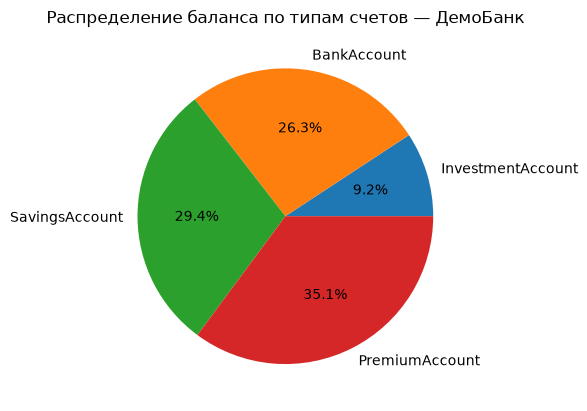


--- 5. Столбчатая диаграмма: балансы клиентов ---


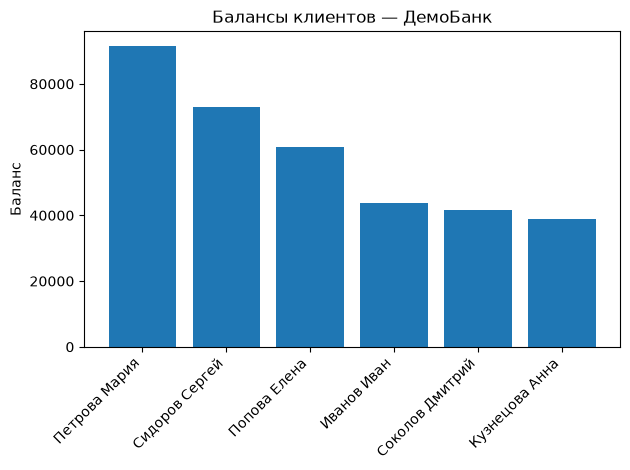


--- 6. График истории баланса счёта ---


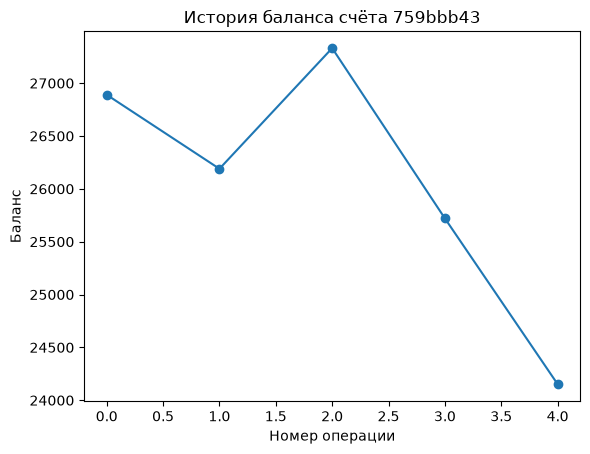


--- 7. Экспорт отчётов и графиков в файлы ---


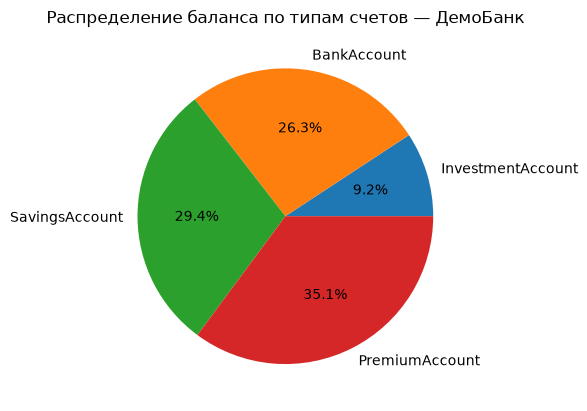

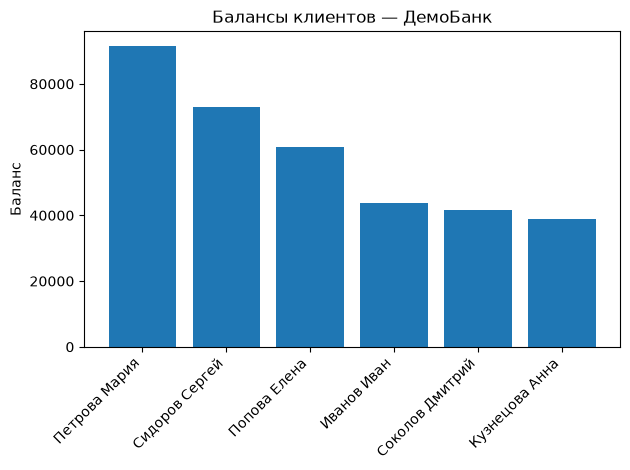

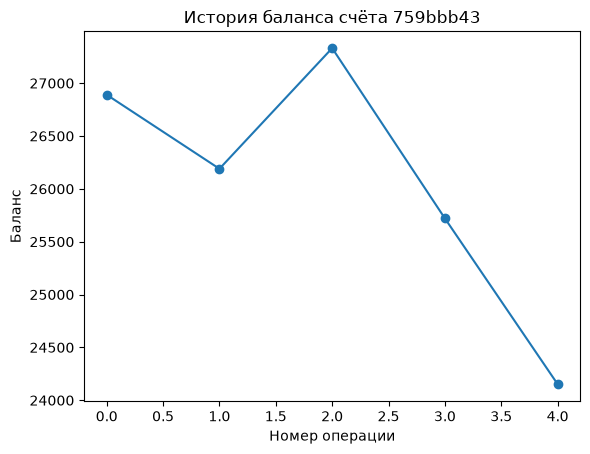

JSON отчёт сохранён: final_bank_report.json
CSV отчёт сохранён: final_client_report.csv
Графики сохранены: ['./chart_accounts_by_type.png', './chart_client_balances.png', './chart_balance_history.png']


In [72]:
print("=== День 7: Демонстрация системы отчётности и визуализации ===")

report_builder2 = ReportBuilder(demo_bank, risk_analyzer=demo_processor.risk_analyzer, audit_log=demo_processor.audit_log)

print("\n--- 1. Текстовый отчёт по клиенту ---")
print(report_builder2.client_report(demo_clients[0].client_id, format="text"))

print("\n--- 2. Текстовый отчёт по банку ---")
print(report_builder2.bank_report(format="text"))

print("\n--- 3. Текстовый отчёт по рискам ---")
print(report_builder2.risk_report(format="text"))

print("\n--- 4. Круговая диаграмма: балансы по типам счетов ---")
report_builder2.pie_chart_accounts_by_type()

print("\n--- 5. Столбчатая диаграмма: балансы клиентов ---")
report_builder2.bar_chart_client_balances()

print("\n--- 6. График истории баланса счёта ---")
report_builder2.line_chart_balance_history(demo_accounts[0].account_id, processed_results)

print("\n--- 7. Экспорт отчётов и графиков в файлы ---")
json_path = report_builder2.export_to_json("bank", "final_bank_report.json")
csv_path = report_builder2.export_to_csv("client", "final_client_report.csv", client_id=demo_clients[0].client_id)
chart_paths = report_builder2.save_charts(account_id=demo_accounts[0].account_id, transactions=processed_results, output_dir=".")

print(f"JSON отчёт сохранён: {json_path}")
print(f"CSV отчёт сохранён: {csv_path}")
print(f"Графики сохранены: {chart_paths}")